# Probabilistic Cost-Effectiveness Analysis for Health Technology Assessment Using Python

## Illustrative Decision Modeling and Uncertainty Propagation

This project demonstrates a transparent, reproducible health-technology-assessment-style cost-effectiveness analysis using Python. It compares two hypothetical strategies:

1. **Standard care**
2. **A hypothetical new health intervention**

The purpose is to illustrate how decision modeling, probabilistic sensitivity analysis, and scenario analysis can support careful interpretation under uncertainty.

The workflow includes:

* A structured model-input table
* A transparent two-strategy decision matrix
* Deterministic base-case analysis
* Incremental cost-effectiveness analysis
* Net monetary benefit across multiple willingness-to-pay thresholds
* Monte Carlo probabilistic sensitivity analysis
* A cost-effectiveness plane
* A cost-effectiveness acceptability curve
* Scenario analysis under alternative assumptions
* Export of clean CSV summary tables and a structured JSON dataset

## Model Scope

The model uses a simplified **one-year cohort decision-tree structure**. Each patient receives either standard care or the hypothetical new intervention. During the one-year period, the patient may experience a main adverse clinical event. The new intervention may reduce the probability of that event but introduces an additional intervention cost and a small probability of a mild intervention-related adverse effect.

The model is intentionally compact so that all assumptions, calculations, and uncertainty distributions remain transparent and easy to audit.

## Interpretation Boundary

> **Important:** This project is an illustrative statistical-computing demonstration using hypothetical input parameters. It is not a clinical recommendation, reimbursement submission, validated decision tool, or substitute for a full health technology assessment informed by clinical evidence, resource-use data, jurisdiction-specific costs, utility studies, and expert review.

All monetary values are expressed in **currency units (CU)** to keep the demonstration jurisdiction-neutral.

## Professional Context

This project demonstrates Python as a supporting statistical-computing capability for transparent decision modeling, uncertainty propagation, and reproducible quantitative interpretation in HEOR and HTA-style settings.


In [1]:
# ============================================================
# PROJECT SETUP AND REQUIRED LIBRARIES
# ============================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Keep notebook output clean while preserving important results
warnings.filterwarnings("ignore")

# Reproducibility settings
RANDOM_SEED = 2026
N_PSA_SIMULATIONS = 10_000
rng = np.random.default_rng(RANDOM_SEED)

# Create a local folder for tables, figures, and JSON exports
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Improve readability of displayed tables
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("Project setup completed successfully.")
print(f"Random seed: {RANDOM_SEED}")
print(f"Planned PSA simulations: {N_PSA_SIMULATIONS:,}")
print(f"Output folder created: {OUTPUT_DIR.resolve()}")

Project setup completed successfully.
Random seed: 2026
Planned PSA simulations: 10,000
Output folder created: /content/outputs


## 1. Structured Illustrative Model Inputs

The table below defines the hypothetical input parameters used in the model. Each value is an illustrative assumption selected to demonstrate transparent health-economic decision modeling and uncertainty propagation.

The parameters do **not** represent evidence for a specific health technology, patient population, clinical guideline, or reimbursement decision. In a real HTA application, the values and uncertainty distributions would require justification using clinical studies, resource-use data, utility evidence, jurisdiction-specific costing, and expert review.


In [2]:
# ============================================================
# STRUCTURED ILLUSTRATIVE MODEL-INPUT TABLE
# ============================================================

model_inputs_df = pd.DataFrame(
    [
        {
            "parameter": "routine_management_cost",
            "description": "One-year routine management cost received under either strategy",
            "category": "Cost",
            "base_case_value": 900.00,
            "unit": "CU",
            "psa_distribution": "Gamma",
            "uncertainty_assumption": "Illustrative mean = 900 CU; SD = 90 CU",
        },
        {
            "parameter": "new_intervention_cost",
            "description": "Additional one-year acquisition or delivery cost of the new intervention",
            "category": "Cost",
            "base_case_value": 800.00,
            "unit": "CU",
            "psa_distribution": "Gamma",
            "uncertainty_assumption": "Illustrative mean = 800 CU; SD = 80 CU",
        },
        {
            "parameter": "main_event_cost",
            "description": "Cost incurred when the main adverse clinical event occurs",
            "category": "Cost",
            "base_case_value": 6500.00,
            "unit": "CU",
            "psa_distribution": "Gamma",
            "uncertainty_assumption": "Illustrative mean = 6,500 CU; SD = 1,300 CU",
        },
        {
            "parameter": "mild_adverse_effect_cost",
            "description": "Cost incurred if a mild intervention-related adverse effect occurs",
            "category": "Cost",
            "base_case_value": 250.00,
            "unit": "CU",
            "psa_distribution": "Gamma",
            "uncertainty_assumption": "Illustrative mean = 250 CU; SD = 50 CU",
        },
        {
            "parameter": "baseline_event_probability",
            "description": "Probability of the main adverse clinical event under standard care",
            "category": "Probability",
            "base_case_value": 0.30,
            "unit": "Probability",
            "psa_distribution": "Beta",
            "uncertainty_assumption": "Illustrative mean = 0.30; effective sample size = 100",
        },
        {
            "parameter": "relative_risk_new_intervention",
            "description": "Relative risk of the main event under the new intervention versus standard care",
            "category": "Treatment effect",
            "base_case_value": 0.68,
            "unit": "Risk ratio",
            "psa_distribution": "Lognormal",
            "uncertainty_assumption": "Illustrative median = 0.68; log-scale SD = 0.12",
        },
        {
            "parameter": "mild_adverse_effect_probability",
            "description": "Probability of a mild intervention-related adverse effect",
            "category": "Probability",
            "base_case_value": 0.06,
            "unit": "Probability",
            "psa_distribution": "Beta",
            "uncertainty_assumption": "Illustrative mean = 0.06; effective sample size = 100",
        },
        {
            "parameter": "baseline_qaly_without_event",
            "description": "One-year QALYs expected when the main event does not occur",
            "category": "Health outcome",
            "base_case_value": 0.86,
            "unit": "QALYs",
            "psa_distribution": "Beta",
            "uncertainty_assumption": "Illustrative mean = 0.86; effective sample size = 100",
        },
        {
            "parameter": "main_event_qaly_loss",
            "description": "QALY loss associated with the main adverse clinical event",
            "category": "Health outcome",
            "base_case_value": 0.08,
            "unit": "QALYs",
            "psa_distribution": "Scaled beta",
            "uncertainty_assumption": "Illustrative mean = 0.08; range = 0.00 to 0.20 QALYs",
        },
        {
            "parameter": "mild_adverse_effect_qaly_loss",
            "description": "QALY loss associated with a mild intervention-related adverse effect",
            "category": "Health outcome",
            "base_case_value": 0.008,
            "unit": "QALYs",
            "psa_distribution": "Scaled beta",
            "uncertainty_assumption": "Illustrative mean = 0.008; range = 0.000 to 0.030 QALYs",
        },
    ]
)

# Create a convenient dictionary for later deterministic calculations
base_case_inputs = (
    model_inputs_df
    .set_index("parameter")["base_case_value"]
    .to_dict()
)

# Basic quality checks
assert model_inputs_df["parameter"].is_unique, "Parameter names must be unique."

probability_parameters = [
    "baseline_event_probability",
    "mild_adverse_effect_probability",
]

for parameter in probability_parameters:
    assert 0 <= base_case_inputs[parameter] <= 1, f"{parameter} must be between 0 and 1."

assert base_case_inputs["relative_risk_new_intervention"] > 0, "Relative risk must be positive."
assert (model_inputs_df.loc[model_inputs_df["category"] == "Cost", "base_case_value"] >= 0).all()

print("Structured illustrative model-input table created successfully.")
print(f"Number of model parameters: {len(model_inputs_df)}")
print("\nImportant: All values are hypothetical demonstration inputs.\n")

display(model_inputs_df)

Structured illustrative model-input table created successfully.
Number of model parameters: 10

Important: All values are hypothetical demonstration inputs.



,parameter,description,category,base_case_value,unit,psa_distribution,uncertainty_assumption
0,routine_management_cost,One-year routine management cost received unde...,Cost,900.0000,CU,Gamma,Illustrative mean = 900 CU; SD = 90 CU
1,new_intervention_cost,Additional one-year acquisition or delivery co...,Cost,800.0000,CU,Gamma,Illustrative mean = 800 CU; SD = 80 CU
2,main_event_cost,Cost incurred when the main adverse clinical e...,Cost,"6,500.0000",CU,Gamma,"Illustrative mean = 6,500 CU; SD = 1,300 CU"
3,mild_adverse_effect_cost,Cost incurred if a mild intervention-related a...,Cost,250.0000,CU,Gamma,Illustrative mean = 250 CU; SD = 50 CU
4,baseline_event_probability,Probability of the main adverse clinical event...,Probability,0.3000,Probability,Beta,Illustrative mean = 0.30; effective sample siz...
5,relative_risk_new_intervention,Relative risk of the main event under the new ...,Treatment effect,0.6800,Risk ratio,Lognormal,Illustrative median = 0.68; log-scale SD = 0.12
6,mild_adverse_effect_probability,Probability of a mild intervention-related adv...,Probability,0.0600,Probability,Beta,Illustrative mean = 0.06; effective sample siz...
7,baseline_qaly_without_event,One-year QALYs expected when the main event do...,Health outcome,0.8600,QALYs,Beta,Illustrative mean = 0.86; effective sample siz...
8,main_event_qaly_loss,QALY loss associated with the main adverse cli...,Health outcome,0.0800,QALYs,Scaled beta,Illustrative mean = 0.08; range = 0.00 to 0.20...
9,mild_adverse_effect_qaly_loss,QALY loss associated with a mild intervention-...,Health outcome,0.0080,QALYs,Scaled beta,Illustrative mean = 0.008; range = 0.000 to 0....


## 2. Transparent Two-Strategy Decision Matrix

The decision matrix translates the illustrative model inputs into expected costs and expected health outcomes for each strategy.

For **standard care**, the model includes routine management costs and the expected consequences of the main adverse clinical event.

For the **new intervention**, the model includes routine management costs, the additional intervention cost, the reduced probability of the main adverse clinical event, and the expected consequences of a mild intervention-related adverse effect.

Expected values are calculated at the cohort level for one representative patient over the one-year model horizon.


In [3]:
# ============================================================
# TRANSPARENT TWO-STRATEGY DECISION MATRIX
# ============================================================

def calculate_strategy_outcomes(inputs):
    """
    Calculate deterministic expected costs and QALYs for:
    1. Standard care
    2. Hypothetical new intervention

    All values are calculated for one representative patient
    over the one-year model horizon.
    """

    # Clinical-event probabilities
    standard_event_probability = inputs["baseline_event_probability"]

    new_intervention_event_probability = np.clip(
        inputs["baseline_event_probability"]
        * inputs["relative_risk_new_intervention"],
        0,
        1,
    )

    mild_adverse_effect_probability = inputs["mild_adverse_effect_probability"]

    # Expected costs: standard care
    standard_routine_cost = inputs["routine_management_cost"]
    standard_expected_main_event_cost = (
        standard_event_probability * inputs["main_event_cost"]
    )
    standard_expected_mild_adverse_effect_cost = 0.0

    standard_total_expected_cost = (
        standard_routine_cost
        + standard_expected_main_event_cost
        + standard_expected_mild_adverse_effect_cost
    )

    # Expected costs: new intervention
    new_routine_cost = inputs["routine_management_cost"]
    new_intervention_cost = inputs["new_intervention_cost"]
    new_expected_main_event_cost = (
        new_intervention_event_probability * inputs["main_event_cost"]
    )
    new_expected_mild_adverse_effect_cost = (
        mild_adverse_effect_probability
        * inputs["mild_adverse_effect_cost"]
    )

    new_total_expected_cost = (
        new_routine_cost
        + new_intervention_cost
        + new_expected_main_event_cost
        + new_expected_mild_adverse_effect_cost
    )

    # Expected QALYs: standard care
    standard_baseline_qalys = inputs["baseline_qaly_without_event"]
    standard_expected_main_event_qaly_loss = (
        standard_event_probability
        * inputs["main_event_qaly_loss"]
    )
    standard_expected_mild_adverse_effect_qaly_loss = 0.0

    standard_total_expected_qalys = (
        standard_baseline_qalys
        - standard_expected_main_event_qaly_loss
        - standard_expected_mild_adverse_effect_qaly_loss
    )

    # Expected QALYs: new intervention
    new_baseline_qalys = inputs["baseline_qaly_without_event"]
    new_expected_main_event_qaly_loss = (
        new_intervention_event_probability
        * inputs["main_event_qaly_loss"]
    )
    new_expected_mild_adverse_effect_qaly_loss = (
        mild_adverse_effect_probability
        * inputs["mild_adverse_effect_qaly_loss"]
    )

    new_total_expected_qalys = (
        new_baseline_qalys
        - new_expected_main_event_qaly_loss
        - new_expected_mild_adverse_effect_qaly_loss
    )

    # Detailed decision matrix
    decision_matrix = pd.DataFrame(
        [
            {
                "component": "Main adverse clinical event probability",
                "category": "Probability",
                "standard_care": standard_event_probability,
                "new_intervention": new_intervention_event_probability,
                "unit": "Probability",
            },
            {
                "component": "Mild intervention-related adverse-effect probability",
                "category": "Probability",
                "standard_care": 0.0,
                "new_intervention": mild_adverse_effect_probability,
                "unit": "Probability",
            },
            {
                "component": "Routine management cost",
                "category": "Expected cost",
                "standard_care": standard_routine_cost,
                "new_intervention": new_routine_cost,
                "unit": "CU",
            },
            {
                "component": "Additional intervention cost",
                "category": "Expected cost",
                "standard_care": 0.0,
                "new_intervention": new_intervention_cost,
                "unit": "CU",
            },
            {
                "component": "Expected main-event cost",
                "category": "Expected cost",
                "standard_care": standard_expected_main_event_cost,
                "new_intervention": new_expected_main_event_cost,
                "unit": "CU",
            },
            {
                "component": "Expected mild adverse-effect cost",
                "category": "Expected cost",
                "standard_care": standard_expected_mild_adverse_effect_cost,
                "new_intervention": new_expected_mild_adverse_effect_cost,
                "unit": "CU",
            },
            {
                "component": "Total expected cost",
                "category": "Expected cost",
                "standard_care": standard_total_expected_cost,
                "new_intervention": new_total_expected_cost,
                "unit": "CU",
            },
            {
                "component": "Baseline QALYs without the main event",
                "category": "Expected health outcome",
                "standard_care": standard_baseline_qalys,
                "new_intervention": new_baseline_qalys,
                "unit": "QALYs",
            },
            {
                "component": "Expected QALY loss from the main event",
                "category": "Expected health outcome",
                "standard_care": standard_expected_main_event_qaly_loss,
                "new_intervention": new_expected_main_event_qaly_loss,
                "unit": "QALYs",
            },
            {
                "component": "Expected QALY loss from mild adverse effects",
                "category": "Expected health outcome",
                "standard_care": standard_expected_mild_adverse_effect_qaly_loss,
                "new_intervention": new_expected_mild_adverse_effect_qaly_loss,
                "unit": "QALYs",
            },
            {
                "component": "Total expected QALYs",
                "category": "Expected health outcome",
                "standard_care": standard_total_expected_qalys,
                "new_intervention": new_total_expected_qalys,
                "unit": "QALYs",
            },
        ]
    )

    # Concise strategy-level summary for later calculations
    strategy_summary = pd.DataFrame(
        [
            {
                "strategy": "Standard care",
                "expected_cost_cu": standard_total_expected_cost,
                "expected_qalys": standard_total_expected_qalys,
                "main_event_probability": standard_event_probability,
                "mild_adverse_effect_probability": 0.0,
            },
            {
                "strategy": "New intervention",
                "expected_cost_cu": new_total_expected_cost,
                "expected_qalys": new_total_expected_qalys,
                "main_event_probability": new_intervention_event_probability,
                "mild_adverse_effect_probability": mild_adverse_effect_probability,
            },
        ]
    )

    return decision_matrix, strategy_summary


decision_matrix_df, strategy_summary_df = calculate_strategy_outcomes(
    base_case_inputs
)

print("Transparent two-strategy decision matrix created successfully.")
print("\nDetailed decision matrix:\n")
display(decision_matrix_df)

print("\nConcise strategy-level summary:\n")
display(strategy_summary_df)

Transparent two-strategy decision matrix created successfully.

Detailed decision matrix:



,component,category,standard_care,new_intervention,unit
0,Main adverse clinical event probability,Probability,0.3000,0.2040,Probability
1,Mild intervention-related adverse-effect proba...,Probability,0.0000,0.0600,Probability
2,Routine management cost,Expected cost,900.0000,900.0000,CU
3,Additional intervention cost,Expected cost,0.0000,800.0000,CU
4,Expected main-event cost,Expected cost,"1,950.0000","1,326.0000",CU
5,Expected mild adverse-effect cost,Expected cost,0.0000,15.0000,CU
6,Total expected cost,Expected cost,"2,850.0000","3,041.0000",CU
7,Baseline QALYs without the main event,Expected health outcome,0.8600,0.8600,QALYs
8,Expected QALY loss from the main event,Expected health outcome,0.0240,0.0163,QALYs
9,Expected QALY loss from mild adverse effects,Expected health outcome,0.0000,0.0005,QALYs



Concise strategy-level summary:



,strategy,expected_cost_cu,expected_qalys,main_event_probability,mild_adverse_effect_probability
0,Standard care,"2,850.0000",0.8360,0.3000,0.0000
1,New intervention,"3,041.0000",0.8432,0.2040,0.0600


## 3. Deterministic Base-Case Cost-Effectiveness Analysis

The deterministic base-case analysis compares the expected costs and expected QALYs of the hypothetical new intervention with standard care.

The incremental cost is calculated as:

**Expected cost of the new intervention − expected cost of standard care**

The incremental effectiveness is calculated as:

**Expected QALYs with the new intervention − expected QALYs with standard care**

When the new intervention is both more costly and more effective, the incremental cost-effectiveness ratio (ICER) represents the additional cost per additional QALY gained.

The ICER should not be interpreted in isolation. Later sections will examine net monetary benefit, probabilistic uncertainty, and scenario sensitivity.


In [4]:
# ============================================================
# DETERMINISTIC BASE-CASE COST-EFFECTIVENESS ANALYSIS
# ============================================================

standard_care_results = (
    strategy_summary_df
    .loc[strategy_summary_df["strategy"] == "Standard care"]
    .iloc[0]
)

new_intervention_results = (
    strategy_summary_df
    .loc[strategy_summary_df["strategy"] == "New intervention"]
    .iloc[0]
)

incremental_cost = (
    new_intervention_results["expected_cost_cu"]
    - standard_care_results["expected_cost_cu"]
)

incremental_qalys = (
    new_intervention_results["expected_qalys"]
    - standard_care_results["expected_qalys"]
)

# Interpret the position of the new intervention on the cost-effectiveness plane
if incremental_cost < 0 and incremental_qalys > 0:
    cost_effectiveness_status = (
        "Dominant: the new intervention is less costly and more effective."
    )
    icer = np.nan

elif incremental_cost > 0 and incremental_qalys < 0:
    cost_effectiveness_status = (
        "Dominated: the new intervention is more costly and less effective."
    )
    icer = np.nan

elif incremental_qalys == 0:
    cost_effectiveness_status = (
        "No incremental QALY difference: an ICER is not informative."
    )
    icer = np.nan

else:
    icer = incremental_cost / incremental_qalys

    if incremental_cost > 0 and incremental_qalys > 0:
        cost_effectiveness_status = (
            "The new intervention is more costly and more effective."
        )
    else:
        cost_effectiveness_status = (
            "The new intervention is less costly and less effective. "
            "Interpretation depends on the acceptable QALY trade-off."
        )

base_case_results_df = pd.DataFrame(
    [
        {
            "comparison": "New intervention vs standard care",
            "standard_care_expected_cost_cu": standard_care_results["expected_cost_cu"],
            "new_intervention_expected_cost_cu": new_intervention_results["expected_cost_cu"],
            "incremental_cost_cu": incremental_cost,
            "standard_care_expected_qalys": standard_care_results["expected_qalys"],
            "new_intervention_expected_qalys": new_intervention_results["expected_qalys"],
            "incremental_qalys": incremental_qalys,
            "icer_cu_per_qaly": icer,
            "interpretation": cost_effectiveness_status,
        }
    ]
)

print("Deterministic base-case cost-effectiveness analysis completed successfully.\n")
display(base_case_results_df)

print("\nBase-case interpretation:")
print(cost_effectiveness_status)

if not np.isnan(icer):
    print(f"Base-case ICER: {icer:,.2f} CU per additional QALY gained.")
else:
    print("Base-case ICER: Not applicable.")

Deterministic base-case cost-effectiveness analysis completed successfully.



,comparison,standard_care_expected_cost_cu,new_intervention_expected_cost_cu,incremental_cost_cu,standard_care_expected_qalys,new_intervention_expected_qalys,incremental_qalys,icer_cu_per_qaly,interpretation
0,New intervention vs standard care,"2,850.0000","3,041.0000",191.0000,0.8360,0.8432,0.0072,"26,527.7778",The new intervention is more costly and more e...



Base-case interpretation:
The new intervention is more costly and more effective.
Base-case ICER: 26,527.78 CU per additional QALY gained.


## 4. Net Monetary Benefit Across Willingness-to-Pay Thresholds

Net monetary benefit (NMB) translates costs and QALYs into a common monetary scale:

**NMB = (Willingness-to-pay threshold × Expected QALYs) − Expected cost**

The incremental net monetary benefit is calculated as:

**Incremental NMB = NMB of the new intervention − NMB of standard care**

A positive incremental NMB favors the hypothetical new intervention at the specified willingness-to-pay threshold. A negative incremental NMB favors standard care.

The willingness-to-pay values used below are illustrative decision thresholds expressed in currency units per QALY. They are not official reimbursement thresholds for any jurisdiction.


In [5]:
# ============================================================
# NET MONETARY BENEFIT ACROSS WILLINGNESS-TO-PAY THRESHOLDS
# ============================================================

# Selected thresholds for the concise summary table
selected_wtp_thresholds = np.array(
    [0, 10_000, 20_000, 30_000, 40_000, 50_000, 60_000]
)

# Continuous threshold range retained for later visualization
wtp_threshold_range = np.arange(0, 60_001, 1_000)

def calculate_nmb_table(thresholds, strategy_summary):
    """
    Calculate strategy-level and incremental net monetary benefit
    across a set of willingness-to-pay thresholds.
    """

    standard = (
        strategy_summary
        .loc[strategy_summary["strategy"] == "Standard care"]
        .iloc[0]
    )

    new = (
        strategy_summary
        .loc[strategy_summary["strategy"] == "New intervention"]
        .iloc[0]
    )

    records = []

    for threshold in thresholds:
        standard_nmb = (
            threshold * standard["expected_qalys"]
            - standard["expected_cost_cu"]
        )

        new_intervention_nmb = (
            threshold * new["expected_qalys"]
            - new["expected_cost_cu"]
        )

        incremental_nmb = new_intervention_nmb - standard_nmb

        favored_strategy = (
            "New intervention"
            if incremental_nmb > 0
            else "Standard care"
            if incremental_nmb < 0
            else "Equivalent NMB"
        )

        records.append(
            {
                "wtp_threshold_cu_per_qaly": threshold,
                "standard_care_nmb_cu": standard_nmb,
                "new_intervention_nmb_cu": new_intervention_nmb,
                "incremental_nmb_cu": incremental_nmb,
                "favored_strategy": favored_strategy,
            }
        )

    return pd.DataFrame(records)


selected_nmb_results_df = calculate_nmb_table(
    selected_wtp_thresholds,
    strategy_summary_df,
)

nmb_threshold_curve_df = calculate_nmb_table(
    wtp_threshold_range,
    strategy_summary_df,
)

# Break-even threshold where incremental NMB equals zero
if incremental_qalys > 0:
    break_even_threshold = incremental_cost / incremental_qalys
else:
    break_even_threshold = np.nan

print("Net monetary benefit analysis completed successfully.\n")
display(selected_nmb_results_df)

if not np.isnan(break_even_threshold):
    print(
        "\nBreak-even willingness-to-pay threshold: "
        f"{break_even_threshold:,.2f} CU per QALY."
    )

print(
    "\nInterpretation: Below the break-even threshold, standard care is favored. "
    "Above the break-even threshold, the hypothetical new intervention is favored."
)

Net monetary benefit analysis completed successfully.



,wtp_threshold_cu_per_qaly,standard_care_nmb_cu,new_intervention_nmb_cu,incremental_nmb_cu,favored_strategy
0,0,"-2,850.0000","-3,041.0000",-191.0000,Standard care
1,10000,"5,510.0000","5,391.0000",-119.0000,Standard care
2,20000,"13,870.0000","13,823.0000",-47.0000,Standard care
3,30000,"22,230.0000","22,255.0000",25.0000,New intervention
4,40000,"30,590.0000","30,687.0000",97.0000,New intervention
5,50000,"38,950.0000","39,119.0000",169.0000,New intervention
6,60000,"47,310.0000","47,551.0000",241.0000,New intervention



Break-even willingness-to-pay threshold: 26,527.78 CU per QALY.

Interpretation: Below the break-even threshold, standard care is favored. Above the break-even threshold, the hypothetical new intervention is favored.


### Visualizing Incremental Net Monetary Benefit

The figure below shows the incremental net monetary benefit of the hypothetical new intervention across a range of illustrative willingness-to-pay thresholds.

Values above zero favor the new intervention. Values below zero favor standard care. The point at which the curve crosses zero represents the break-even willingness-to-pay threshold.

This visualization should not be interpreted as a reimbursement recommendation. It shows how the preferred strategy changes under different illustrative decision thresholds.


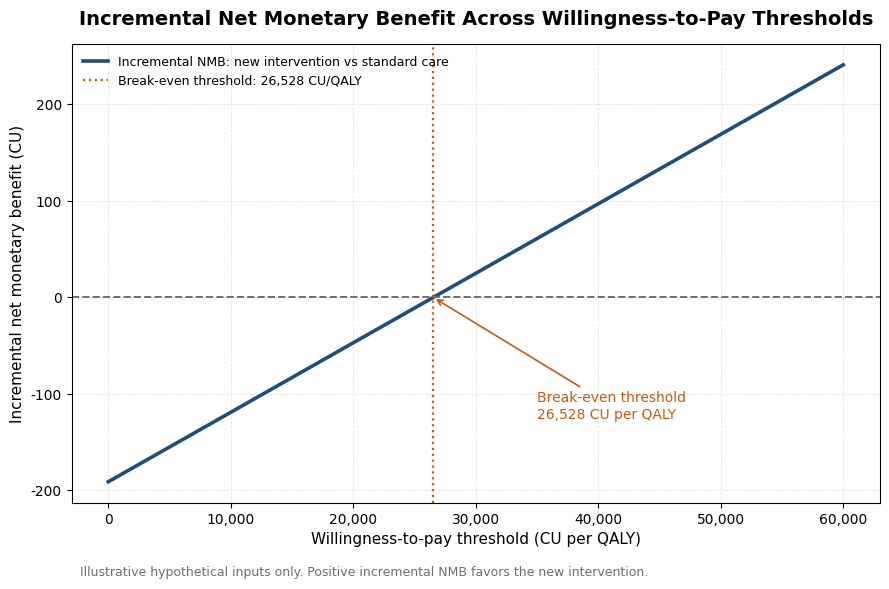

Net monetary benefit figure created successfully.
Saved figure: outputs/net_monetary_benefit_by_threshold.png


In [6]:
# ============================================================
# PUBLICATION-STYLE NET MONETARY BENEFIT FIGURE
# ============================================================

from matplotlib.ticker import FuncFormatter

# Professional figure palette
PRIMARY_BLUE = "#1F4E79"
REFERENCE_ORANGE = "#C55A11"
NEUTRAL_GRAY = "#6E6E6E"

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    nmb_threshold_curve_df["wtp_threshold_cu_per_qaly"],
    nmb_threshold_curve_df["incremental_nmb_cu"],
    linewidth=2.6,
    color=PRIMARY_BLUE,
    label="Incremental NMB: new intervention vs standard care",
)

# Horizontal line: no difference in net monetary benefit
ax.axhline(
    y=0,
    linewidth=1.4,
    linestyle="--",
    color=NEUTRAL_GRAY,
)

# Vertical line: break-even willingness-to-pay threshold
ax.axvline(
    x=break_even_threshold,
    linewidth=1.6,
    linestyle=":",
    color=REFERENCE_ORANGE,
    label=f"Break-even threshold: {break_even_threshold:,.0f} CU/QALY",
)

# Add an annotation near the break-even point
ax.annotate(
    f"Break-even threshold\n{break_even_threshold:,.0f} CU per QALY",
    xy=(break_even_threshold, 0),
    xytext=(35_000, -125),
    arrowprops={
        "arrowstyle": "->",
        "color": REFERENCE_ORANGE,
        "linewidth": 1.2,
    },
    fontsize=10,
    color=REFERENCE_ORANGE,
)

ax.set_title(
    "Incremental Net Monetary Benefit Across Willingness-to-Pay Thresholds",
    fontsize=14,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(
    "Willingness-to-pay threshold (CU per QALY)",
    fontsize=11,
)

ax.set_ylabel(
    "Incremental net monetary benefit (CU)",
    fontsize=11,
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.0f}")
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.0f}")
)

ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35,
)

ax.legend(
    frameon=False,
    loc="upper left",
    fontsize=9,
)

ax.text(
    0.01,
    -0.16,
    "Illustrative hypothetical inputs only. Positive incremental NMB favors the new intervention.",
    transform=ax.transAxes,
    fontsize=9,
    color=NEUTRAL_GRAY,
)

plt.tight_layout()

nmb_figure_path = OUTPUT_DIR / "net_monetary_benefit_by_threshold.png"

plt.savefig(
    nmb_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Net monetary benefit figure created successfully.")
print(f"Saved figure: {nmb_figure_path}")

## 5. Probabilistic Sensitivity Analysis: Distribution Specifications

A deterministic base case represents only one combination of model inputs. Probabilistic sensitivity analysis (PSA) examines decision uncertainty by repeatedly drawing uncertain parameters from specified probability distributions and recalculating the model.

The illustrative PSA uses:

* **Gamma distributions** for costs because costs must remain positive and may be right-skewed.
* **Beta distributions** for probabilities and baseline QALYs because these values are bounded between zero and one.
* A **lognormal distribution** for the relative risk because a risk ratio must remain positive.
* **Scaled beta distributions** for QALY losses because these values are bounded within explicitly defined plausible ranges.

The distributions and uncertainty assumptions are hypothetical demonstration inputs. They are not estimates derived from clinical studies, utility studies, or jurisdiction-specific costing evidence.


In [7]:
# ============================================================
# PSA DISTRIBUTION SPECIFICATIONS AND VALIDATION
# ============================================================

# Each specification is intentionally illustrative.
# In a real HTA model, these assumptions would require
# evidence-based justification and expert review.

psa_parameter_specs = {
    "routine_management_cost": {
        "distribution": "Gamma",
        "mean": 900.00,
        "sd": 90.00,
    },
    "new_intervention_cost": {
        "distribution": "Gamma",
        "mean": 800.00,
        "sd": 80.00,
    },
    "main_event_cost": {
        "distribution": "Gamma",
        "mean": 6500.00,
        "sd": 1300.00,
    },
    "mild_adverse_effect_cost": {
        "distribution": "Gamma",
        "mean": 250.00,
        "sd": 50.00,
    },
    "baseline_event_probability": {
        "distribution": "Beta",
        "mean": 0.30,
        "effective_sample_size": 100,
    },
    "relative_risk_new_intervention": {
        "distribution": "Lognormal",
        "median": 0.68,
        "log_sd": 0.12,
    },
    "mild_adverse_effect_probability": {
        "distribution": "Beta",
        "mean": 0.06,
        "effective_sample_size": 100,
    },
    "baseline_qaly_without_event": {
        "distribution": "Beta",
        "mean": 0.86,
        "effective_sample_size": 100,
    },
    "main_event_qaly_loss": {
        "distribution": "Scaled beta",
        "mean": 0.08,
        "lower_bound": 0.00,
        "upper_bound": 0.20,
        "effective_sample_size": 60,
    },
    "mild_adverse_effect_qaly_loss": {
        "distribution": "Scaled beta",
        "mean": 0.008,
        "lower_bound": 0.000,
        "upper_bound": 0.030,
        "effective_sample_size": 60,
    },
}


def gamma_shape_scale(mean, sd):
    """Convert a gamma mean and SD into shape and scale parameters."""
    shape = (mean / sd) ** 2
    scale = (sd ** 2) / mean
    return shape, scale


def beta_alpha_beta(mean, effective_sample_size):
    """Convert a beta mean and effective sample size into alpha and beta."""
    alpha = mean * effective_sample_size
    beta = (1 - mean) * effective_sample_size
    return alpha, beta


def scaled_beta_alpha_beta(mean, lower_bound, upper_bound, effective_sample_size):
    """
    Convert a bounded mean into alpha and beta parameters
    for a scaled beta distribution.
    """
    scaled_mean = (mean - lower_bound) / (upper_bound - lower_bound)
    alpha = scaled_mean * effective_sample_size
    beta = (1 - scaled_mean) * effective_sample_size
    return alpha, beta


def sample_parameter(specification, n_draws, random_generator):
    """Generate random draws from one PSA distribution specification."""

    distribution = specification["distribution"]

    if distribution == "Gamma":
        shape, scale = gamma_shape_scale(
            specification["mean"],
            specification["sd"],
        )

        return random_generator.gamma(
            shape=shape,
            scale=scale,
            size=n_draws,
        )

    if distribution == "Beta":
        alpha, beta = beta_alpha_beta(
            specification["mean"],
            specification["effective_sample_size"],
        )

        return random_generator.beta(
            a=alpha,
            b=beta,
            size=n_draws,
        )

    if distribution == "Lognormal":
        return random_generator.lognormal(
            mean=np.log(specification["median"]),
            sigma=specification["log_sd"],
            size=n_draws,
        )

    if distribution == "Scaled beta":
        alpha, beta = scaled_beta_alpha_beta(
            specification["mean"],
            specification["lower_bound"],
            specification["upper_bound"],
            specification["effective_sample_size"],
        )

        unscaled_draws = random_generator.beta(
            a=alpha,
            b=beta,
            size=n_draws,
        )

        return (
            specification["lower_bound"]
            + unscaled_draws
            * (
                specification["upper_bound"]
                - specification["lower_bound"]
            )
        )

    raise ValueError(f"Unsupported distribution: {distribution}")


# Use a dedicated random-number generator for reproducible PSA inputs
psa_rng = np.random.default_rng(RANDOM_SEED)

psa_input_draws_df = pd.DataFrame(
    {
        parameter: sample_parameter(
            specification,
            N_PSA_SIMULATIONS,
            psa_rng,
        )
        for parameter, specification in psa_parameter_specs.items()
    }
)

# ------------------------------------------------------------
# Quality checks
# ------------------------------------------------------------

assert psa_input_draws_df.shape == (
    N_PSA_SIMULATIONS,
    len(psa_parameter_specs),
)

assert not psa_input_draws_df.isna().any().any()

cost_parameters = [
    "routine_management_cost",
    "new_intervention_cost",
    "main_event_cost",
    "mild_adverse_effect_cost",
]

probability_parameters = [
    "baseline_event_probability",
    "mild_adverse_effect_probability",
    "baseline_qaly_without_event",
]

for parameter in cost_parameters:
    assert (psa_input_draws_df[parameter] >= 0).all()

for parameter in probability_parameters:
    assert psa_input_draws_df[parameter].between(0, 1).all()

assert (psa_input_draws_df["relative_risk_new_intervention"] > 0).all()

assert psa_input_draws_df["main_event_qaly_loss"].between(
    0.00,
    0.20,
).all()

assert psa_input_draws_df["mild_adverse_effect_qaly_loss"].between(
    0.000,
    0.030,
).all()

# ------------------------------------------------------------
# Diagnostic summary
# ------------------------------------------------------------

psa_input_diagnostic_summary_df = pd.DataFrame(
    [
        {
            "parameter": parameter,
            "distribution": specification["distribution"],
            "base_case_value": base_case_inputs[parameter],
            "simulated_mean": psa_input_draws_df[parameter].mean(),
            "simulated_sd": psa_input_draws_df[parameter].std(ddof=1),
            "simulated_median": psa_input_draws_df[parameter].median(),
            "lower_2.5_percentile": psa_input_draws_df[parameter].quantile(0.025),
            "upper_97.5_percentile": psa_input_draws_df[parameter].quantile(0.975),
        }
        for parameter, specification in psa_parameter_specs.items()
    ]
)

print("PSA distributions defined and sampled successfully.")
print(f"Number of sampled parameter sets: {len(psa_input_draws_df):,}")
print("All sampled values passed validity checks.\n")

display(psa_input_diagnostic_summary_df)

PSA distributions defined and sampled successfully.
Number of sampled parameter sets: 10,000
All sampled values passed validity checks.



,parameter,distribution,base_case_value,simulated_mean,simulated_sd,simulated_median,lower_2.5_percentile,upper_97.5_percentile
0,routine_management_cost,Gamma,900.0000,899.0950,89.8679,897.3453,732.7432,"1,081.9871"
1,new_intervention_cost,Gamma,800.0000,800.5246,79.1405,797.7727,651.7639,964.8414
2,main_event_cost,Gamma,"6,500.0000","6,496.2910","1,294.1672","6,418.0107","4,215.9361","9,240.5582"
3,mild_adverse_effect_cost,Gamma,250.0000,250.5789,50.4766,247.4285,161.9095,359.7258
4,baseline_event_probability,Beta,0.3000,0.3003,0.0450,0.2995,0.2180,0.3923
5,relative_risk_new_intervention,Lognormal,0.6800,0.6865,0.0829,0.6808,0.5387,0.8644
6,mild_adverse_effect_probability,Beta,0.0600,0.0602,0.0237,0.0572,0.0224,0.1144
7,baseline_qaly_without_event,Beta,0.8600,0.8601,0.0346,0.8627,0.7850,0.9204
8,main_event_qaly_loss,Scaled beta,0.0800,0.0801,0.0127,0.0796,0.0563,0.1055
9,mild_adverse_effect_qaly_loss,Scaled beta,0.0080,0.0080,0.0017,0.0079,0.0050,0.0116


## 6. Propagating Parameter Uncertainty Through the Model

The model is recalculated for each simulated parameter set. This produces a distribution of plausible expected costs, expected QALYs, incremental costs, and incremental QALYs.

The results should be interpreted as an illustration of decision uncertainty under the specified hypothetical assumptions. They do not represent clinical evidence or a reimbursement recommendation.

The cost-effectiveness-plane quadrants indicate whether the hypothetical new intervention is:

* More costly and more effective
* Less costly and more effective
* More costly and less effective
* Less costly and less effective


In [8]:
# ============================================================
# PROPAGATE PSA INPUTS THROUGH THE DECISION MODEL
# ============================================================

# Main-event probabilities
psa_standard_event_probability = (
    psa_input_draws_df["baseline_event_probability"]
)

psa_new_intervention_event_probability = np.clip(
    psa_input_draws_df["baseline_event_probability"]
    * psa_input_draws_df["relative_risk_new_intervention"],
    0,
    1,
)

# ------------------------------------------------------------
# Expected costs
# ------------------------------------------------------------

psa_standard_care_expected_cost = (
    psa_input_draws_df["routine_management_cost"]
    + psa_standard_event_probability
    * psa_input_draws_df["main_event_cost"]
)

psa_new_intervention_expected_cost = (
    psa_input_draws_df["routine_management_cost"]
    + psa_input_draws_df["new_intervention_cost"]
    + psa_new_intervention_event_probability
    * psa_input_draws_df["main_event_cost"]
    + psa_input_draws_df["mild_adverse_effect_probability"]
    * psa_input_draws_df["mild_adverse_effect_cost"]
)

# ------------------------------------------------------------
# Expected QALYs
# ------------------------------------------------------------

psa_standard_care_expected_qalys = (
    psa_input_draws_df["baseline_qaly_without_event"]
    - psa_standard_event_probability
    * psa_input_draws_df["main_event_qaly_loss"]
)

psa_new_intervention_expected_qalys = (
    psa_input_draws_df["baseline_qaly_without_event"]
    - psa_new_intervention_event_probability
    * psa_input_draws_df["main_event_qaly_loss"]
    - psa_input_draws_df["mild_adverse_effect_probability"]
    * psa_input_draws_df["mild_adverse_effect_qaly_loss"]
)

# ------------------------------------------------------------
# Incremental outcomes
# ------------------------------------------------------------

psa_incremental_cost = (
    psa_new_intervention_expected_cost
    - psa_standard_care_expected_cost
)

psa_incremental_qalys = (
    psa_new_intervention_expected_qalys
    - psa_standard_care_expected_qalys
)

# Calculate ICERs for completeness, but do not use them as the
# primary PSA summary because ratios can become unstable near zero.
psa_icer = np.where(
    np.abs(psa_incremental_qalys) > 1e-12,
    psa_incremental_cost / psa_incremental_qalys,
    np.nan,
)

# ------------------------------------------------------------
# Cost-effectiveness-plane quadrants
# ------------------------------------------------------------

psa_ce_quadrant = np.select(
    [
        (psa_incremental_cost >= 0) & (psa_incremental_qalys >= 0),
        (psa_incremental_cost < 0) & (psa_incremental_qalys >= 0),
        (psa_incremental_cost >= 0) & (psa_incremental_qalys < 0),
        (psa_incremental_cost < 0) & (psa_incremental_qalys < 0),
    ],
    [
        "North-east: more costly and more effective",
        "North-west: dominant (less costly and more effective)",
        "South-east: dominated (more costly and less effective)",
        "South-west: less costly and less effective",
    ],
    default="Unclassified",
)

# ------------------------------------------------------------
# Store simulation-level results
# ------------------------------------------------------------

psa_results_df = pd.DataFrame(
    {
        "simulation_id": np.arange(1, N_PSA_SIMULATIONS + 1),
        "standard_care_expected_cost_cu": psa_standard_care_expected_cost,
        "new_intervention_expected_cost_cu": psa_new_intervention_expected_cost,
        "incremental_cost_cu": psa_incremental_cost,
        "standard_care_expected_qalys": psa_standard_care_expected_qalys,
        "new_intervention_expected_qalys": psa_new_intervention_expected_qalys,
        "incremental_qalys": psa_incremental_qalys,
        "icer_cu_per_qaly": psa_icer,
        "ce_quadrant": psa_ce_quadrant,
    }
)

# ------------------------------------------------------------
# Validity checks
# ------------------------------------------------------------

assert len(psa_results_df) == N_PSA_SIMULATIONS
assert not psa_results_df[
    [
        "standard_care_expected_cost_cu",
        "new_intervention_expected_cost_cu",
        "incremental_cost_cu",
        "standard_care_expected_qalys",
        "new_intervention_expected_qalys",
        "incremental_qalys",
    ]
].isna().any().any()

# ------------------------------------------------------------
# PSA outcome summary
# ------------------------------------------------------------

psa_summary_variables = [
    "standard_care_expected_cost_cu",
    "new_intervention_expected_cost_cu",
    "incremental_cost_cu",
    "standard_care_expected_qalys",
    "new_intervention_expected_qalys",
    "incremental_qalys",
]

psa_outcome_summary_df = pd.DataFrame(
    [
        {
            "outcome": variable,
            "mean": psa_results_df[variable].mean(),
            "sd": psa_results_df[variable].std(ddof=1),
            "median": psa_results_df[variable].median(),
            "lower_2.5_percentile": psa_results_df[variable].quantile(0.025),
            "upper_97.5_percentile": psa_results_df[variable].quantile(0.975),
        }
        for variable in psa_summary_variables
    ]
)

psa_quadrant_summary_df = (
    psa_results_df["ce_quadrant"]
    .value_counts()
    .rename_axis("cost_effectiveness_plane_quadrant")
    .reset_index(name="number_of_simulations")
)

psa_quadrant_summary_df["proportion"] = (
    psa_quadrant_summary_df["number_of_simulations"]
    / N_PSA_SIMULATIONS
)

print("PSA outcomes calculated successfully.")
print(f"Number of completed model simulations: {len(psa_results_df):,}")
print("\nPSA outcome summary:\n")
display(psa_outcome_summary_df)

print("\nCost-effectiveness-plane quadrant summary:\n")
display(psa_quadrant_summary_df)

PSA outcomes calculated successfully.
Number of completed model simulations: 10,000

PSA outcome summary:



,outcome,mean,sd,median,lower_2.5_percentile,upper_97.5_percentile
0,standard_care_expected_cost_cu,"2,849.1823",495.4679,"2,804.8862","2,024.2124","3,937.0811"
1,new_intervention_expected_cost_cu,"3,053.0457",391.5993,"3,015.5950","2,401.5188","3,930.9127"
2,incremental_cost_cu,203.8634,240.6847,221.2539,-316.4323,625.1707
3,standard_care_expected_qalys,0.8360,0.0350,0.8388,0.7600,0.8980
4,new_intervention_expected_qalys,0.8431,0.0349,0.8457,0.7675,0.9050
5,incremental_qalys,0.0071,0.0026,0.0069,0.0023,0.0127



Cost-effectiveness-plane quadrant summary:



,cost_effectiveness_plane_quadrant,number_of_simulations,proportion
0,North-east: more costly and more effective,8044,0.8044
1,North-west: dominant (less costly and more eff...,1941,0.1941
2,South-east: dominated (more costly and less ef...,15,0.0015


### Cost-Effectiveness Plane

The cost-effectiveness plane visualizes the joint uncertainty in incremental costs and incremental QALYs.

Each point represents one probabilistic sensitivity-analysis simulation comparing the hypothetical new intervention with standard care.

* Points in the **north-east quadrant** indicate that the new intervention is more effective and more costly.
* Points in the **north-west quadrant** indicate dominance: the new intervention is more effective and less costly.
* Points in the **south-east quadrant** indicate that the new intervention is less effective and more costly.
* Points in the **south-west quadrant** indicate that the new intervention is less costly and less effective.

The diagonal line represents an illustrative willingness-to-pay threshold of **30,000 CU per QALY**. Points below this line have a positive incremental net monetary benefit at that threshold.

The figure illustrates uncertainty under hypothetical assumptions. It is not a reimbursement recommendation.


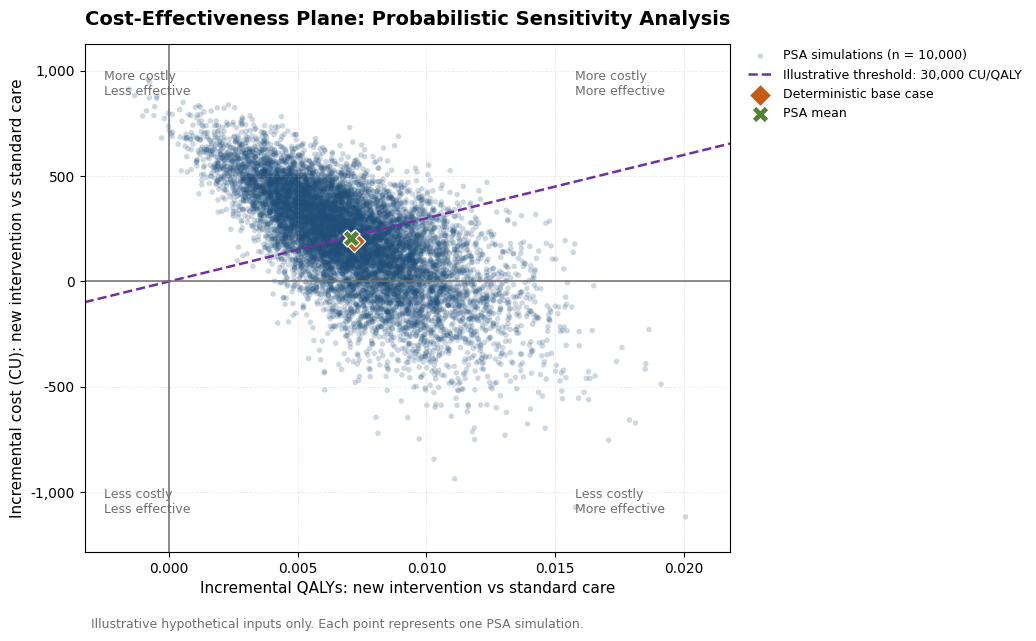

Cost-effectiveness plane created successfully.
Saved figure: outputs/cost_effectiveness_plane.png
PSA mean result: 203.86 CU and 0.0071 incremental QALYs.


In [10]:
# ============================================================
# PUBLICATION-STYLE COST-EFFECTIVENESS PLANE
# ============================================================

from matplotlib.ticker import FuncFormatter

# Professional figure palette
PSA_BLUE = "#1F4E79"
BASE_CASE_ORANGE = "#C55A11"
PSA_MEAN_GREEN = "#548235"
REFERENCE_GRAY = "#6E6E6E"
WTP_PURPLE = "#7030A0"

illustrative_wtp_line = 30_000

# Dynamic axis ranges with padding so that all simulations remain visible
x_min = min(psa_results_df["incremental_qalys"].min(), 0)
x_max = max(psa_results_df["incremental_qalys"].max(), 0)

y_min = min(psa_results_df["incremental_cost_cu"].min(), 0)
y_max = max(psa_results_df["incremental_cost_cu"].max(), 0)

x_padding = max((x_max - x_min) * 0.08, 0.001)
y_padding = max((y_max - y_min) * 0.08, 50)

x_plot_min = x_min - x_padding
x_plot_max = x_max + x_padding

y_plot_min = y_min - y_padding
y_plot_max = y_max + y_padding

# Create the WTP reference line across the full horizontal range
wtp_x_values = np.linspace(x_plot_min, x_plot_max, 200)
wtp_y_values = illustrative_wtp_line * wtp_x_values

fig, ax = plt.subplots(figsize=(10.5, 6.5))

# PSA simulation cloud
ax.scatter(
    psa_results_df["incremental_qalys"],
    psa_results_df["incremental_cost_cu"],
    s=16,
    alpha=0.22,
    color=PSA_BLUE,
    edgecolors="none",
    label=f"PSA simulations (n = {N_PSA_SIMULATIONS:,})",
)

# Illustrative WTP threshold line
ax.plot(
    wtp_x_values,
    wtp_y_values,
    linewidth=1.8,
    linestyle="--",
    color=WTP_PURPLE,
    label=f"Illustrative threshold: {illustrative_wtp_line:,.0f} CU/QALY",
)

# Reference axes
ax.axhline(
    y=0,
    linewidth=1.1,
    color=REFERENCE_GRAY,
)

ax.axvline(
    x=0,
    linewidth=1.1,
    color=REFERENCE_GRAY,
)

# Deterministic base-case result
ax.scatter(
    incremental_qalys,
    incremental_cost,
    s=130,
    marker="D",
    color=BASE_CASE_ORANGE,
    edgecolor="white",
    linewidth=0.9,
    label="Deterministic base case",
    zorder=5,
)

# PSA mean result
psa_mean_incremental_qalys = psa_results_df["incremental_qalys"].mean()
psa_mean_incremental_cost = psa_results_df["incremental_cost_cu"].mean()

ax.scatter(
    psa_mean_incremental_qalys,
    psa_mean_incremental_cost,
    s=150,
    marker="X",
    color=PSA_MEAN_GREEN,
    edgecolor="white",
    linewidth=0.9,
    label="PSA mean",
    zorder=6,
)

# Quadrant labels
ax.text(
    0.03,
    0.95,
    "More costly\nLess effective",
    transform=ax.transAxes,
    fontsize=9,
    color=REFERENCE_GRAY,
    va="top",
)

ax.text(
    0.76,
    0.95,
    "More costly\nMore effective",
    transform=ax.transAxes,
    fontsize=9,
    color=REFERENCE_GRAY,
    va="top",
)

ax.text(
    0.03,
    0.07,
    "Less costly\nLess effective",
    transform=ax.transAxes,
    fontsize=9,
    color=REFERENCE_GRAY,
    va="bottom",
)

ax.text(
    0.76,
    0.07,
    "Less costly\nMore effective",
    transform=ax.transAxes,
    fontsize=9,
    color=REFERENCE_GRAY,
    va="bottom",
)

ax.set_xlim(x_plot_min, x_plot_max)
ax.set_ylim(y_plot_min, y_plot_max)

ax.set_title(
    "Cost-Effectiveness Plane: Probabilistic Sensitivity Analysis",
    fontsize=14,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(
    "Incremental QALYs: new intervention vs standard care",
    fontsize=11,
)

ax.set_ylabel(
    "Incremental cost (CU): new intervention vs standard care",
    fontsize=11,
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:.3f}")
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.0f}")
)

ax.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.25,
)

ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.00),
    borderaxespad=0,
    fontsize=9,
)

ax.text(
    0.01,
    -0.15,
    "Illustrative hypothetical inputs only. Each point represents one PSA simulation.",
    transform=ax.transAxes,
    fontsize=9,
    color=REFERENCE_GRAY,
)

plt.tight_layout()

ce_plane_figure_path = OUTPUT_DIR / "cost_effectiveness_plane.png"

plt.savefig(
    ce_plane_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Cost-effectiveness plane created successfully.")
print(f"Saved figure: {ce_plane_figure_path}")
print(
    f"PSA mean result: {psa_mean_incremental_cost:,.2f} CU "
    f"and {psa_mean_incremental_qalys:.4f} incremental QALYs."
)

### Cost-Effectiveness Acceptability Curve

The cost-effectiveness acceptability curve (CEAC) summarizes decision uncertainty across willingness-to-pay thresholds.

For each simulated parameter set, incremental net monetary benefit is calculated as:

**Incremental NMB = (Willingness-to-pay threshold × Incremental QALYs) − Incremental cost**

The CEAC reports the proportion of probabilistic simulations in which the hypothetical new intervention has a positive incremental net monetary benefit.

A higher probability indicates stronger support for the new intervention under the specified illustrative assumptions. The curve should not be interpreted as a reimbursement recommendation or as evidence for a real health technology.


In [11]:
# ============================================================
# COST-EFFECTIVENESS ACCEPTABILITY CURVE: CALCULATE DATA
# ============================================================

def calculate_ceac_data(
    psa_results,
    thresholds,
):
    """
    Calculate cost-effectiveness probabilities for the hypothetical
    new intervention and standard care across willingness-to-pay thresholds.
    """

    records = []

    for threshold in thresholds:
        incremental_nmb_draws = (
            threshold * psa_results["incremental_qalys"]
            - psa_results["incremental_cost_cu"]
        )

        probability_new_intervention = (
            incremental_nmb_draws > 0
        ).mean()

        probability_standard_care = (
            incremental_nmb_draws < 0
        ).mean()

        probability_equivalent_nmb = (
            incremental_nmb_draws == 0
        ).mean()

        records.append(
            {
                "wtp_threshold_cu_per_qaly": threshold,
                "probability_new_intervention_cost_effective": (
                    probability_new_intervention
                ),
                "probability_standard_care_cost_effective": (
                    probability_standard_care
                ),
                "probability_equivalent_nmb": (
                    probability_equivalent_nmb
                ),
            }
        )

    return pd.DataFrame(records)


ceac_curve_df = calculate_ceac_data(
    psa_results=psa_results_df,
    thresholds=wtp_threshold_range,
)

selected_ceac_results_df = (
    ceac_curve_df
    .loc[
        ceac_curve_df["wtp_threshold_cu_per_qaly"]
        .isin(selected_wtp_thresholds)
    ]
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Quality checks
# ------------------------------------------------------------

assert ceac_curve_df[
    "probability_new_intervention_cost_effective"
].between(0, 1).all()

assert ceac_curve_df[
    "probability_standard_care_cost_effective"
].between(0, 1).all()

assert np.allclose(
    ceac_curve_df[
        [
            "probability_new_intervention_cost_effective",
            "probability_standard_care_cost_effective",
            "probability_equivalent_nmb",
        ]
    ].sum(axis=1),
    1.0,
)

print("Cost-effectiveness acceptability curve data calculated successfully.")
print(
    f"Number of evaluated willingness-to-pay thresholds: "
    f"{len(ceac_curve_df)}"
)
print("\nSelected CEAC results:\n")

display(selected_ceac_results_df)

Cost-effectiveness acceptability curve data calculated successfully.
Number of evaluated willingness-to-pay thresholds: 61

Selected CEAC results:



,wtp_threshold_cu_per_qaly,probability_new_intervention_cost_effective,probability_standard_care_cost_effective,probability_equivalent_nmb
0,0,0.1941,0.8059,0.0000
1,10000,0.2817,0.7183,0.0000
2,20000,0.3870,0.6130,0.0000
3,30000,0.4872,0.5128,0.0000
4,40000,0.5765,0.4235,0.0000
5,50000,0.6547,0.3453,0.0000
6,60000,0.7160,0.2840,0.0000


### Visualizing Decision Uncertainty Across Thresholds

The cost-effectiveness acceptability curve below shows how the probability of cost-effectiveness changes across illustrative willingness-to-pay thresholds.

The two curves represent the probability that each strategy has the highest net monetary benefit under the probabilistic sensitivity-analysis assumptions.

The horizontal reference line at 50% helps identify thresholds at which decision uncertainty remains substantial. The highlighted point at **30,000 CU per QALY** illustrates that a favorable deterministic ICER does not necessarily imply a high probability that the new intervention is cost-effective.

The results remain illustrative and should not be interpreted as a reimbursement recommendation.


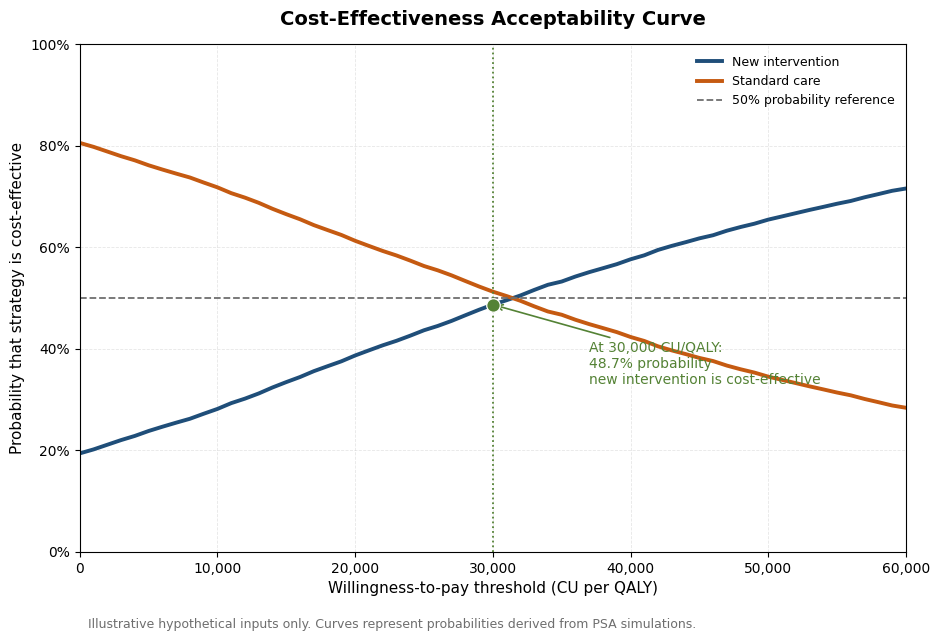

Cost-effectiveness acceptability curve created successfully.
Saved figure: outputs/cost_effectiveness_acceptability_curve.png
Probability that the new intervention is cost-effective at 30,000 CU per QALY: 48.72%


In [12]:
# ============================================================
# PUBLICATION-STYLE COST-EFFECTIVENESS ACCEPTABILITY CURVE
# ============================================================

from matplotlib.ticker import FuncFormatter, PercentFormatter

# Professional figure palette
NEW_INTERVENTION_BLUE = "#1F4E79"
STANDARD_CARE_ORANGE = "#C55A11"
REFERENCE_GRAY = "#6E6E6E"
HIGHLIGHT_GREEN = "#548235"

highlight_threshold = 30_000

highlight_probability = (
    ceac_curve_df
    .loc[
        ceac_curve_df["wtp_threshold_cu_per_qaly"]
        == highlight_threshold,
        "probability_new_intervention_cost_effective",
    ]
    .iloc[0]
)

fig, ax = plt.subplots(figsize=(9.5, 6.5))

# New-intervention CEAC
ax.plot(
    ceac_curve_df["wtp_threshold_cu_per_qaly"],
    ceac_curve_df["probability_new_intervention_cost_effective"],
    linewidth=2.8,
    color=NEW_INTERVENTION_BLUE,
    label="New intervention",
)

# Standard-care CEAC
ax.plot(
    ceac_curve_df["wtp_threshold_cu_per_qaly"],
    ceac_curve_df["probability_standard_care_cost_effective"],
    linewidth=2.8,
    color=STANDARD_CARE_ORANGE,
    label="Standard care",
)

# Horizontal reference line at 50%
ax.axhline(
    y=0.50,
    linewidth=1.3,
    linestyle="--",
    color=REFERENCE_GRAY,
    label="50% probability reference",
)

# Vertical reference line at the highlighted threshold
ax.axvline(
    x=highlight_threshold,
    linewidth=1.3,
    linestyle=":",
    color=HIGHLIGHT_GREEN,
)

# Highlight the new-intervention probability at 30,000 CU/QALY
ax.scatter(
    highlight_threshold,
    highlight_probability,
    s=95,
    color=HIGHLIGHT_GREEN,
    edgecolor="white",
    linewidth=0.9,
    zorder=5,
)

ax.annotate(
    (
        f"At {highlight_threshold:,.0f} CU/QALY:\n"
        f"{highlight_probability:.1%} probability\n"
        "new intervention is cost-effective"
    ),
    xy=(highlight_threshold, highlight_probability),
    xytext=(37_000, 0.33),
    arrowprops={
        "arrowstyle": "->",
        "color": HIGHLIGHT_GREEN,
        "linewidth": 1.2,
    },
    fontsize=10,
    color=HIGHLIGHT_GREEN,
)

ax.set_title(
    "Cost-Effectiveness Acceptability Curve",
    fontsize=14,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(
    "Willingness-to-pay threshold (CU per QALY)",
    fontsize=11,
)

ax.set_ylabel(
    "Probability that strategy is cost-effective",
    fontsize=11,
)

ax.set_xlim(
    ceac_curve_df["wtp_threshold_cu_per_qaly"].min(),
    ceac_curve_df["wtp_threshold_cu_per_qaly"].max(),
)

ax.set_ylim(0, 1)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.0f}")
)

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=1.0)
)

ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.30,
)

ax.legend(
    frameon=False,
    loc="upper right",
    fontsize=9,
)

ax.text(
    0.01,
    -0.15,
    (
        "Illustrative hypothetical inputs only. "
        "Curves represent probabilities derived from PSA simulations."
    ),
    transform=ax.transAxes,
    fontsize=9,
    color=REFERENCE_GRAY,
)

plt.tight_layout()

ceac_figure_path = (
    OUTPUT_DIR
    / "cost_effectiveness_acceptability_curve.png"
)

plt.savefig(
    ceac_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Cost-effectiveness acceptability curve created successfully.")
print(f"Saved figure: {ceac_figure_path}")
print(
    f"Probability that the new intervention is cost-effective "
    f"at {highlight_threshold:,.0f} CU per QALY: "
    f"{highlight_probability:.2%}"
)

## 7. Deterministic Scenario Analysis

Scenario analysis examines whether the cost-effectiveness conclusion changes under alternative assumptions.

The scenarios below vary clinically and economically important parameters while preserving the same transparent one-year decision-tree structure.

The analysis includes:

* A **base-case scenario**
* A **more conservative treatment-effect scenario**
* A **higher intervention-cost scenario**
* A **higher-risk population scenario**
* A **combined unfavorable scenario**

The results illustrate how decision conclusions may depend on treatment effectiveness, intervention price, baseline clinical risk, and adverse-effect assumptions.

These scenarios are hypothetical demonstrations. They are not evidence-based policy recommendations.


In [13]:
# ============================================================
# DETERMINISTIC SCENARIO ANALYSIS
# ============================================================

from copy import deepcopy

SCENARIO_WTP_THRESHOLD = 30_000


def calculate_scenario_results(
    scenario_name,
    scenario_description,
    scenario_inputs,
    wtp_threshold=SCENARIO_WTP_THRESHOLD,
):
    """
    Calculate deterministic cost-effectiveness results for one scenario.
    """

    _, scenario_strategy_summary = calculate_strategy_outcomes(
        scenario_inputs
    )

    standard = (
        scenario_strategy_summary
        .loc[
            scenario_strategy_summary["strategy"] == "Standard care"
        ]
        .iloc[0]
    )

    new = (
        scenario_strategy_summary
        .loc[
            scenario_strategy_summary["strategy"] == "New intervention"
        ]
        .iloc[0]
    )

    scenario_incremental_cost = (
        new["expected_cost_cu"]
        - standard["expected_cost_cu"]
    )

    scenario_incremental_qalys = (
        new["expected_qalys"]
        - standard["expected_qalys"]
    )

    scenario_incremental_nmb = (
        wtp_threshold * scenario_incremental_qalys
        - scenario_incremental_cost
    )

    if scenario_incremental_cost < 0 and scenario_incremental_qalys > 0:
        scenario_status = "Dominant"
        scenario_icer = np.nan

    elif scenario_incremental_cost > 0 and scenario_incremental_qalys < 0:
        scenario_status = "Dominated"
        scenario_icer = np.nan

    elif scenario_incremental_qalys == 0:
        scenario_status = "No incremental QALY difference"
        scenario_icer = np.nan

    else:
        scenario_icer = (
            scenario_incremental_cost
            / scenario_incremental_qalys
        )

        if scenario_incremental_cost > 0 and scenario_incremental_qalys > 0:
            scenario_status = "More costly and more effective"

        elif scenario_incremental_cost < 0 and scenario_incremental_qalys < 0:
            scenario_status = "Less costly and less effective"

        else:
            scenario_status = "Mixed cost-effectiveness pattern"

    favored_strategy = (
        "New intervention"
        if scenario_incremental_nmb > 0
        else "Standard care"
        if scenario_incremental_nmb < 0
        else "Equivalent NMB"
    )

    return {
        "scenario": scenario_name,
        "description": scenario_description,
        "baseline_event_probability": (
            scenario_inputs["baseline_event_probability"]
        ),
        "relative_risk_new_intervention": (
            scenario_inputs["relative_risk_new_intervention"]
        ),
        "new_intervention_cost_cu": (
            scenario_inputs["new_intervention_cost"]
        ),
        "mild_adverse_effect_probability": (
            scenario_inputs["mild_adverse_effect_probability"]
        ),
        "standard_care_expected_cost_cu": (
            standard["expected_cost_cu"]
        ),
        "new_intervention_expected_cost_cu": (
            new["expected_cost_cu"]
        ),
        "incremental_cost_cu": scenario_incremental_cost,
        "standard_care_expected_qalys": (
            standard["expected_qalys"]
        ),
        "new_intervention_expected_qalys": (
            new["expected_qalys"]
        ),
        "incremental_qalys": scenario_incremental_qalys,
        "icer_cu_per_qaly": scenario_icer,
        "cost_effectiveness_status": scenario_status,
        "incremental_nmb_at_30000_cu": scenario_incremental_nmb,
        "favored_strategy_at_30000_cu_per_qaly": favored_strategy,
    }


# ------------------------------------------------------------
# Define scenario-specific assumptions
# ------------------------------------------------------------

scenario_definitions = []

# 1. Base case
scenario_definitions.append(
    {
        "name": "Base case",
        "description": "Original illustrative assumptions",
        "inputs": deepcopy(base_case_inputs),
    }
)

# 2. More conservative treatment effect
conservative_effect_inputs = deepcopy(base_case_inputs)
conservative_effect_inputs[
    "relative_risk_new_intervention"
] = 0.82

scenario_definitions.append(
    {
        "name": "More conservative treatment effect",
        "description": (
            "Relative risk increased from 0.68 to 0.82"
        ),
        "inputs": conservative_effect_inputs,
    }
)

# 3. Higher intervention cost
higher_cost_inputs = deepcopy(base_case_inputs)
higher_cost_inputs["new_intervention_cost"] = 1100.00

scenario_definitions.append(
    {
        "name": "Higher intervention cost",
        "description": (
            "Additional intervention cost increased "
            "from 800 CU to 1,100 CU"
        ),
        "inputs": higher_cost_inputs,
    }
)

# 4. Higher-risk population
higher_risk_inputs = deepcopy(base_case_inputs)
higher_risk_inputs["baseline_event_probability"] = 0.45

scenario_definitions.append(
    {
        "name": "Higher-risk population",
        "description": (
            "Baseline event probability increased "
            "from 0.30 to 0.45"
        ),
        "inputs": higher_risk_inputs,
    }
)

# 5. Combined unfavorable scenario
combined_unfavorable_inputs = deepcopy(base_case_inputs)
combined_unfavorable_inputs[
    "relative_risk_new_intervention"
] = 0.82
combined_unfavorable_inputs["new_intervention_cost"] = 1100.00
combined_unfavorable_inputs[
    "mild_adverse_effect_probability"
] = 0.10
combined_unfavorable_inputs[
    "mild_adverse_effect_cost"
] = 350.00

scenario_definitions.append(
    {
        "name": "Combined unfavorable scenario",
        "description": (
            "Weaker treatment effect, higher intervention cost, "
            "and greater mild adverse-effect burden"
        ),
        "inputs": combined_unfavorable_inputs,
    }
)

# ------------------------------------------------------------
# Calculate scenario results
# ------------------------------------------------------------

scenario_results_df = pd.DataFrame(
    [
        calculate_scenario_results(
            scenario_name=scenario["name"],
            scenario_description=scenario["description"],
            scenario_inputs=scenario["inputs"],
        )
        for scenario in scenario_definitions
    ]
)

# ------------------------------------------------------------
# Quality checks
# ------------------------------------------------------------

assert len(scenario_results_df) == 5

assert not scenario_results_df[
    [
        "incremental_cost_cu",
        "incremental_qalys",
        "incremental_nmb_at_30000_cu",
    ]
].isna().any().any()

print("Deterministic scenario analysis completed successfully.")
print(f"Number of evaluated scenarios: {len(scenario_results_df)}")
print(
    "Illustrative willingness-to-pay threshold used for "
    f"scenario NMB comparison: {SCENARIO_WTP_THRESHOLD:,.0f} CU per QALY.\n"
)

display(
    scenario_results_df[
        [
            "scenario",
            "incremental_cost_cu",
            "incremental_qalys",
            "icer_cu_per_qaly",
            "cost_effectiveness_status",
            "incremental_nmb_at_30000_cu",
            "favored_strategy_at_30000_cu_per_qaly",
        ]
    ]
)

Deterministic scenario analysis completed successfully.
Number of evaluated scenarios: 5
Illustrative willingness-to-pay threshold used for scenario NMB comparison: 30,000 CU per QALY.



,scenario,incremental_cost_cu,incremental_qalys,icer_cu_per_qaly,cost_effectiveness_status,incremental_nmb_at_30000_cu,favored_strategy_at_30000_cu_per_qaly
0,Base case,191.0000,0.0072,"26,527.7778",More costly and more effective,25.0000,New intervention
1,More conservative treatment effect,464.0000,0.0038,"120,833.3333",More costly and more effective,-348.8000,Standard care
2,Higher intervention cost,491.0000,0.0072,"68,194.4444",More costly and more effective,-275.0000,Standard care
3,Higher-risk population,-121.0000,0.0110,NaN,Dominant,452.2000,New intervention
4,Combined unfavorable scenario,784.0000,0.0035,"222,727.2727",More costly and more effective,-678.4000,Standard care


### Visualizing Scenario Sensitivity

The figure below compares incremental net monetary benefit across deterministic scenarios at an illustrative willingness-to-pay threshold of **30,000 CU per QALY**.

Positive incremental net monetary benefit favors the hypothetical new intervention. Negative values favor standard care.

The results demonstrate that cost-effectiveness conclusions can change when assumptions about intervention price, treatment effect, baseline clinical risk, and adverse-effect burden are modified.

The figure is an illustrative methodological demonstration. It is not a clinical or reimbursement recommendation.


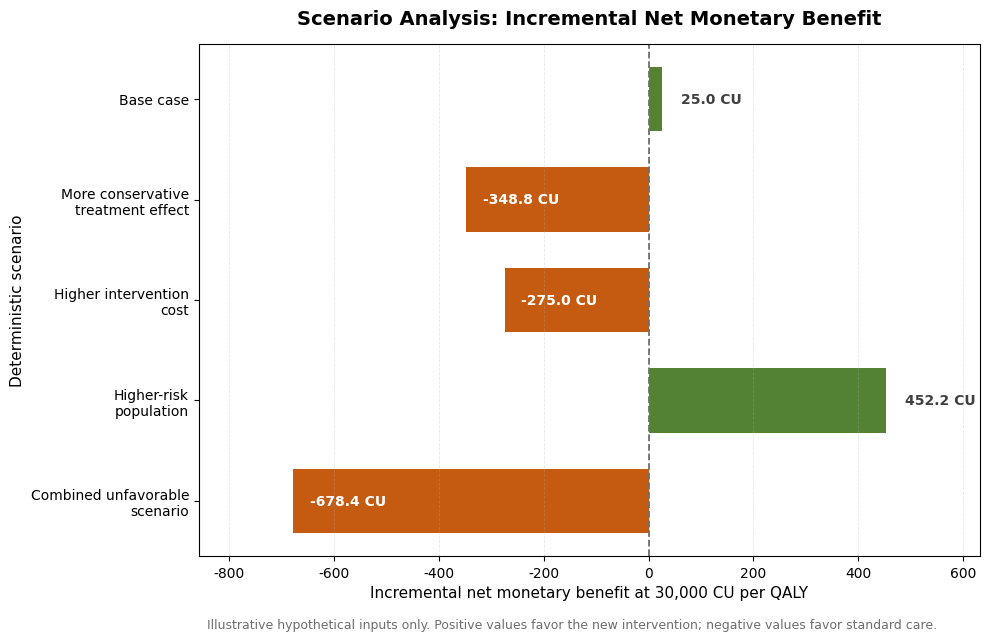

Scenario-analysis summary figure created successfully.
Saved figure: outputs/scenario_analysis_summary.png


In [18]:
# ============================================================
# PUBLICATION-STYLE SCENARIO-ANALYSIS SUMMARY FIGURE
# ============================================================

from matplotlib.ticker import FuncFormatter

# Professional figure palette
FAVORS_INTERVENTION_GREEN = "#548235"
FAVORS_STANDARD_CARE_ORANGE = "#C55A11"
REFERENCE_GRAY = "#6E6E6E"
TEXT_GRAY = "#404040"

scenario_plot_df = (
    scenario_results_df[
        [
            "scenario",
            "incremental_nmb_at_30000_cu",
        ]
    ]
    .copy()
)

# Shorten labels slightly for a clean figure
scenario_label_map = {
    "Base case": "Base case",
    "More conservative treatment effect": "More conservative\ntreatment effect",
    "Higher intervention cost": "Higher intervention\ncost",
    "Higher-risk population": "Higher-risk\npopulation",
    "Combined unfavorable scenario": "Combined unfavorable\nscenario",
}

scenario_plot_df["display_label"] = (
    scenario_plot_df["scenario"]
    .map(scenario_label_map)
)

scenario_plot_df["bar_color"] = np.where(
    scenario_plot_df["incremental_nmb_at_30000_cu"] >= 0,
    FAVORS_INTERVENTION_GREEN,
    FAVORS_STANDARD_CARE_ORANGE,
)

# Reverse the order so the base case appears at the top
scenario_plot_df = (
    scenario_plot_df
    .iloc[::-1]
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6.5))

bars = ax.barh(
    scenario_plot_df["display_label"],
    scenario_plot_df["incremental_nmb_at_30000_cu"],
    color=scenario_plot_df["bar_color"],
    height=0.64,
)

# Add horizontal padding so that all value labels remain readable
minimum_nmb = scenario_plot_df["incremental_nmb_at_30000_cu"].min()
maximum_nmb = scenario_plot_df["incremental_nmb_at_30000_cu"].max()

ax.set_xlim(
    minimum_nmb - 180,
    maximum_nmb + 180,
)

# Decision boundary
ax.axvline(
    x=0,
    linewidth=1.3,
    linestyle="--",
    color=REFERENCE_GRAY,
)

# Add readable value labels:
# positive values outside the bars; negative values inside the bars
for bar, value in zip(
    bars,
    scenario_plot_df["incremental_nmb_at_30000_cu"],
):
    y_position = bar.get_y() + bar.get_height() / 2

    if value >= 0:
        ax.annotate(
            f"{value:,.1f} CU",
            xy=(value, y_position),
            xytext=(14, 0),
            textcoords="offset points",
            va="center",
            ha="left",
            fontsize=10,
            color=TEXT_GRAY,
            fontweight="bold",
        )

    else:
        ax.annotate(
            f"{value:,.1f} CU",
            xy=(value, y_position),
            xytext=(12, 0),
            textcoords="offset points",
            va="center",
            ha="left",
            fontsize=10,
            color="white",
            fontweight="bold",
        )

ax.set_title(
    "Scenario Analysis: Incremental Net Monetary Benefit",
    fontsize=14,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(
    "Incremental net monetary benefit at 30,000 CU per QALY",
    fontsize=11,
)

ax.set_ylabel(
    "Deterministic scenario",
    fontsize=11,
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:,.0f}")
)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.30,
)



ax.text(
    0.01,
    -0.14,
    (
        "Illustrative hypothetical inputs only. "
        "Positive values favor the new intervention; "
        "negative values favor standard care."
    ),
    transform=ax.transAxes,
    fontsize=9,
    color=REFERENCE_GRAY,
)

plt.tight_layout()

scenario_figure_path = (
    OUTPUT_DIR
    / "scenario_analysis_summary.png"
)

plt.savefig(
    scenario_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Scenario-analysis summary figure created successfully.")
print(f"Saved figure: {scenario_figure_path}")

## 8. Exporting Reproducible Summary Tables

The analysis outputs are exported as clean CSV files to support reproducibility, transparent review, and reuse in GitHub documentation, portfolio materials, and professional presentations.

The exported tables include:

- Deterministic base-case cost-effectiveness results
- Probabilistic sensitivity-analysis summary results
- Deterministic scenario-analysis results

The files contain illustrative modeling outputs only and should not be interpreted as clinical evidence or reimbursement recommendations.

In [19]:
# ============================================================
# EXPORT CLEAN CSV SUMMARY TABLES
# ============================================================

# ------------------------------------------------------------
# 1. Deterministic base-case results
# ------------------------------------------------------------

hta_base_case_export_df = base_case_results_df.copy()

base_case_csv_path = (
    OUTPUT_DIR
    / "hta_base_case_results.csv"
)

hta_base_case_export_df.to_csv(
    base_case_csv_path,
    index=False,
)

# ------------------------------------------------------------
# 2. PSA summary results
# ------------------------------------------------------------

# Combine outcome summaries and quadrant proportions in one
# clean export table while preserving clear result types.

psa_outcome_export_df = (
    psa_outcome_summary_df
    .copy()
)

psa_outcome_export_df.insert(
    0,
    "summary_type",
    "PSA outcome distribution",
)

psa_outcome_export_df = (
    psa_outcome_export_df
    .rename(columns={"outcome": "metric"})
)

psa_quadrant_export_df = (
    psa_quadrant_summary_df
    .copy()
)

psa_quadrant_export_df.insert(
    0,
    "summary_type",
    "Cost-effectiveness-plane quadrant",
)

psa_quadrant_export_df = (
    psa_quadrant_export_df
    .rename(
        columns={
            "cost_effectiveness_plane_quadrant": "metric",
        }
    )
)

# Add compatible columns so the two summary sections
# can be exported together cleanly.
for column in [
    "mean",
    "sd",
    "median",
    "lower_2.5_percentile",
    "upper_97.5_percentile",
]:
    psa_quadrant_export_df[column] = np.nan

for column in [
    "number_of_simulations",
    "proportion",
]:
    psa_outcome_export_df[column] = np.nan

hta_psa_summary_export_df = pd.concat(
    [
        psa_outcome_export_df,
        psa_quadrant_export_df,
    ],
    ignore_index=True,
)

hta_psa_summary_export_df = (
    hta_psa_summary_export_df[
        [
            "summary_type",
            "metric",
            "mean",
            "sd",
            "median",
            "lower_2.5_percentile",
            "upper_97.5_percentile",
            "number_of_simulations",
            "proportion",
        ]
    ]
)

psa_summary_csv_path = (
    OUTPUT_DIR
    / "hta_psa_summary.csv"
)

hta_psa_summary_export_df.to_csv(
    psa_summary_csv_path,
    index=False,
)

# ------------------------------------------------------------
# 3. Deterministic scenario results
# ------------------------------------------------------------

hta_scenario_results_export_df = (
    scenario_results_df
    .copy()
)

scenario_results_csv_path = (
    OUTPUT_DIR
    / "hta_scenario_results.csv"
)

hta_scenario_results_export_df.to_csv(
    scenario_results_csv_path,
    index=False,
)

# ------------------------------------------------------------
# Confirm exported files
# ------------------------------------------------------------

exported_csv_files = [
    base_case_csv_path,
    psa_summary_csv_path,
    scenario_results_csv_path,
]

print("CSV summary tables exported successfully.\n")

for file_path in exported_csv_files:
    print(f"- {file_path}")

print("\nBase-case CSV preview:\n")
display(hta_base_case_export_df)

print("\nPSA-summary CSV preview:\n")
display(hta_psa_summary_export_df)

print("\nScenario-results CSV preview:\n")
display(hta_scenario_results_export_df)

CSV summary tables exported successfully.

- outputs/hta_base_case_results.csv
- outputs/hta_psa_summary.csv
- outputs/hta_scenario_results.csv

Base-case CSV preview:



,comparison,standard_care_expected_cost_cu,new_intervention_expected_cost_cu,incremental_cost_cu,standard_care_expected_qalys,new_intervention_expected_qalys,incremental_qalys,icer_cu_per_qaly,interpretation
0,New intervention vs standard care,"2,850.0000","3,041.0000",191.0000,0.8360,0.8432,0.0072,"26,527.7778",The new intervention is more costly and more e...



PSA-summary CSV preview:



,summary_type,metric,mean,sd,median,lower_2.5_percentile,upper_97.5_percentile,number_of_simulations,proportion
0,PSA outcome distribution,standard_care_expected_cost_cu,"2,849.1823",495.4679,"2,804.8862","2,024.2124","3,937.0811",NaN,NaN
1,PSA outcome distribution,new_intervention_expected_cost_cu,"3,053.0457",391.5993,"3,015.5950","2,401.5188","3,930.9127",NaN,NaN
2,PSA outcome distribution,incremental_cost_cu,203.8634,240.6847,221.2539,-316.4323,625.1707,NaN,NaN
3,PSA outcome distribution,standard_care_expected_qalys,0.8360,0.0350,0.8388,0.7600,0.8980,NaN,NaN
4,PSA outcome distribution,new_intervention_expected_qalys,0.8431,0.0349,0.8457,0.7675,0.9050,NaN,NaN
5,PSA outcome distribution,incremental_qalys,0.0071,0.0026,0.0069,0.0023,0.0127,NaN,NaN
6,Cost-effectiveness-plane quadrant,North-east: more costly and more effective,NaN,NaN,NaN,NaN,NaN,"8,044.0000",0.8044
7,Cost-effectiveness-plane quadrant,North-west: dominant (less costly and more eff...,NaN,NaN,NaN,NaN,NaN,"1,941.0000",0.1941
8,Cost-effectiveness-plane quadrant,South-east: dominated (more costly and less ef...,NaN,NaN,NaN,NaN,NaN,15.0000,0.0015



Scenario-results CSV preview:



,scenario,description,baseline_event_probability,relative_risk_new_intervention,new_intervention_cost_cu,mild_adverse_effect_probability,standard_care_expected_cost_cu,new_intervention_expected_cost_cu,incremental_cost_cu,standard_care_expected_qalys,new_intervention_expected_qalys,incremental_qalys,icer_cu_per_qaly,cost_effectiveness_status,incremental_nmb_at_30000_cu,favored_strategy_at_30000_cu_per_qaly
0,Base case,Original illustrative assumptions,0.3000,0.6800,800.0000,0.0600,"2,850.0000","3,041.0000",191.0000,0.8360,0.8432,0.0072,"26,527.7778",More costly and more effective,25.0000,New intervention
1,More conservative treatment effect,Relative risk increased from 0.68 to 0.82,0.3000,0.8200,800.0000,0.0600,"2,850.0000","3,314.0000",464.0000,0.8360,0.8398,0.0038,"120,833.3333",More costly and more effective,-348.8000,Standard care
2,Higher intervention cost,Additional intervention cost increased from 80...,0.3000,0.6800,"1,100.0000",0.0600,"2,850.0000","3,341.0000",491.0000,0.8360,0.8432,0.0072,"68,194.4444",More costly and more effective,-275.0000,Standard care
3,Higher-risk population,Baseline event probability increased from 0.30...,0.4500,0.6800,800.0000,0.0600,"3,825.0000","3,704.0000",-121.0000,0.8240,0.8350,0.0110,NaN,Dominant,452.2000,New intervention
4,Combined unfavorable scenario,"Weaker treatment effect, higher intervention c...",0.3000,0.8200,"1,100.0000",0.1000,"2,850.0000","3,634.0000",784.0000,0.8360,0.8395,0.0035,"222,727.2727",More costly and more effective,-678.4000,Standard care


## 9. Exporting a Structured JSON Dataset

A structured JSON file is exported to preserve the model assumptions, deterministic results, probabilistic uncertainty summaries, cost-effectiveness acceptability results, and scenario-analysis outputs in a reusable machine-readable format.

This supports reproducibility and transparent communication while keeping the illustrative nature of the project explicit.

The JSON dataset contains hypothetical demonstration inputs only. It is not a validated HTA model, clinical recommendation, or reimbursement submission.


In [20]:
# ============================================================
# EXPORT STRUCTURED JSON DATASET
# ============================================================

def dataframe_to_json_records(dataframe):
    """
    Convert a pandas DataFrame into JSON-safe records.
    Missing values are exported as null.
    """
    return json.loads(
        dataframe.to_json(
            orient="records",
            double_precision=10,
        )
    )


def make_json_safe(value):
    """
    Recursively convert NumPy and pandas values into standard
    Python values that can be exported safely as JSON.
    """

    if isinstance(value, dict):
        return {
            str(key): make_json_safe(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [
            make_json_safe(item)
            for item in value
        ]

    if isinstance(value, np.ndarray):
        return [
            make_json_safe(item)
            for item in value.tolist()
        ]

    if isinstance(value, np.integer):
        return int(value)

    if isinstance(value, np.floating):
        if np.isnan(value):
            return None

        return float(value)

    if isinstance(value, float):
        if np.isnan(value):
            return None

        return value

    return value


hta_model_export = {
    "project_metadata": {
        "project_title": (
            "Probabilistic Cost-Effectiveness Analysis "
            "for Health Technology Assessment Using Python"
        ),
        "model_type": (
            "Illustrative one-year cohort decision-tree model"
        ),
        "strategies_compared": [
            "Standard care",
            "Hypothetical new health intervention",
        ],
        "currency_unit": "CU",
        "effectiveness_measure": "QALYs",
        "psa_number_of_simulations": N_PSA_SIMULATIONS,
        "random_seed": RANDOM_SEED,
        "interpretation_boundary": (
            "This project is an illustrative statistical-computing "
            "demonstration using hypothetical input parameters. "
            "It is not a clinical recommendation, reimbursement "
            "submission, validated decision tool, or substitute for "
            "a full health technology assessment informed by clinical "
            "evidence, resource-use data, jurisdiction-specific costs, "
            "utility studies, and expert review."
        ),
    },

    "model_inputs": {
        "structured_input_table": dataframe_to_json_records(
            model_inputs_df
        ),
        "base_case_parameter_values": make_json_safe(
            base_case_inputs
        ),
        "psa_distribution_specifications": make_json_safe(
            psa_parameter_specs
        ),
    },

    "deterministic_base_case": {
        "strategy_level_results": dataframe_to_json_records(
            strategy_summary_df
        ),
        "incremental_cost_effectiveness_results": (
            dataframe_to_json_records(
                base_case_results_df
            )
        ),
        "selected_net_monetary_benefit_results": (
            dataframe_to_json_records(
                selected_nmb_results_df
            )
        ),
        "break_even_wtp_threshold_cu_per_qaly": (
            float(break_even_threshold)
        ),
    },

    "probabilistic_sensitivity_analysis": {
        "psa_input_diagnostic_summary": (
            dataframe_to_json_records(
                psa_input_diagnostic_summary_df
            )
        ),
        "psa_outcome_summary": dataframe_to_json_records(
            psa_outcome_summary_df
        ),
        "cost_effectiveness_plane_quadrant_summary": (
            dataframe_to_json_records(
                psa_quadrant_summary_df
            )
        ),
        "selected_ceac_results": dataframe_to_json_records(
            selected_ceac_results_df
        ),
    },

    "scenario_analysis": {
        "wtp_threshold_cu_per_qaly": (
            SCENARIO_WTP_THRESHOLD
        ),
        "scenario_results": dataframe_to_json_records(
            scenario_results_df
        ),
    },

    "exported_files": {
        "figures": [
            "cost_effectiveness_plane.png",
            "cost_effectiveness_acceptability_curve.png",
            "net_monetary_benefit_by_threshold.png",
            "scenario_analysis_summary.png",
        ],
        "summary_tables": [
            "hta_base_case_results.csv",
            "hta_psa_summary.csv",
            "hta_scenario_results.csv",
        ],
        "structured_dataset": "hta_model_export.json",
    },
}

json_export_path = (
    OUTPUT_DIR
    / "hta_model_export.json"
)

with open(
    json_export_path,
    "w",
    encoding="utf-8",
) as json_file:
    json.dump(
        make_json_safe(hta_model_export),
        json_file,
        indent=2,
        ensure_ascii=False,
        allow_nan=False,
    )

# ------------------------------------------------------------
# Confirm JSON export
# ------------------------------------------------------------

with open(
    json_export_path,
    "r",
    encoding="utf-8",
) as json_file:
    validated_json_export = json.load(json_file)

print("Structured JSON dataset exported successfully.")
print(f"Saved JSON file: {json_export_path}")
print(
    f"JSON file size: "
    f"{json_export_path.stat().st_size / 1024:,.2f} KB"
)

print("\nTop-level JSON sections:\n")

for section_name in validated_json_export.keys():
    print(f"- {section_name}")

Structured JSON dataset exported successfully.
Saved JSON file: outputs/hta_model_export.json
JSON file size: 20.83 KB

Top-level JSON sections:

- project_metadata
- model_inputs
- deterministic_base_case
- probabilistic_sensitivity_analysis
- scenario_analysis
- exported_files


## 10. Interpretation, Decision Uncertainty, and Methodological Limitations

### Illustrative Base-Case Interpretation

Under the hypothetical base-case assumptions, the new intervention is slightly more costly and modestly more effective than standard care.

* **Incremental cost:** 191.00 CU
* **Incremental QALYs:** 0.0072
* **ICER:** 26,527.78 CU per additional QALY gained

At an illustrative willingness-to-pay threshold of **30,000 CU per QALY**, the deterministic incremental net monetary benefit is positive but small:

* **Incremental NMB:** 25.00 CU

This suggests that the base-case conclusion is sensitive to uncertainty and should not be interpreted as definitive.

### Probabilistic Interpretation

The probabilistic sensitivity analysis propagates uncertainty in costs, probabilities, treatment effectiveness, and QALY assumptions across **10,000 simulations**.

The cost-effectiveness-plane results show that the hypothetical new intervention is:

* **More costly and more effective** in 80.44% of simulations
* **Less costly and more effective** in 19.41% of simulations
* **More costly and less effective** in 0.15% of simulations

At **30,000 CU per QALY**, the probability that the new intervention is cost-effective is approximately **48.72%**.

This distinction is important: a deterministic ICER below an illustrative decision threshold does not automatically imply a high degree of decision certainty.

### Scenario Interpretation

The deterministic scenario analysis demonstrates that the conclusion changes under alternative assumptions.

* A **more conservative treatment effect** favors standard care.
* A **higher intervention cost** favors standard care.
* A **higher-risk population** makes the new intervention dominant: less costly and more effective.
* A **combined unfavorable scenario** favors standard care clearly.

These findings illustrate that value may depend on the target population, intervention price, treatment effectiveness, and adverse-effect burden.

### Methodological Limitations

This project is a compact statistical-computing demonstration. It deliberately prioritizes transparency and reproducibility over clinical complexity.

Important limitations include:

1. **Hypothetical inputs:** All model parameters, uncertainty assumptions, and scenarios are illustrative. They are not derived from clinical studies, observational data, utility studies, or jurisdiction-specific costing evidence.

2. **Simplified structure:** The model uses a one-year cohort decision-tree framework. It does not model longer-term disease progression, repeated events, competing risks, treatment discontinuation, mortality, or state transitions over time.

3. **No evidence synthesis:** The project does not include systematic literature review, meta-analysis, network meta-analysis, survival extrapolation, or calibration to real-world evidence.

4. **No subgroup estimation:** The higher-risk scenario illustrates population sensitivity but does not represent a validated subgroup analysis or treatment-effect-heterogeneity estimate.

5. **Illustrative uncertainty distributions:** Distribution types are selected appropriately for the parameter scales, but their numerical uncertainty assumptions are not evidence-based.

6. **No jurisdiction-specific policy interpretation:** Monetary values are expressed in currency units (CU), and willingness-to-pay thresholds are illustrative. The results should not be mapped directly onto any health-system reimbursement framework.

7. **No budget-impact analysis:** Cost-effectiveness analysis and budget-impact analysis answer different questions. This project evaluates illustrative value per patient rather than affordability at the population level.

### Interpretation Boundary

> **This project is an illustrative statistical-computing demonstration using hypothetical inputs. It is not a clinical recommendation, reimbursement submission, validated decision tool, or substitute for a full health technology assessment informed by clinical evidence, resource-use data, jurisdiction-specific costs, utility studies, stakeholder input, and expert review.**

### Professional Takeaway

The project demonstrates how Python can support transparent decision modeling, reproducible uncertainty propagation, structured export of results, and careful interpretation in HEOR and HTA-style settings.

Python is used here as a supporting statistical-computing capability within a broader quantitative-consulting approach focused on defensible modeling, uncertainty, and decision relevance.


In [21]:
# ============================================================
# VERIFY FINAL OUTPUT FOLDER
# ============================================================

required_output_files = [
    "cost_effectiveness_plane.png",
    "cost_effectiveness_acceptability_curve.png",
    "net_monetary_benefit_by_threshold.png",
    "scenario_analysis_summary.png",
    "hta_base_case_results.csv",
    "hta_psa_summary.csv",
    "hta_scenario_results.csv",
    "hta_model_export.json",
]

verification_records = []

for file_name in required_output_files:
    file_path = OUTPUT_DIR / file_name

    verification_records.append(
        {
            "file_name": file_name,
            "exists": file_path.exists(),
            "file_size_kb": (
                round(file_path.stat().st_size / 1024, 2)
                if file_path.exists()
                else 0
            ),
            "status": (
                "Ready"
                if file_path.exists()
                and file_path.stat().st_size > 0
                else "Missing or empty"
            ),
        }
    )

output_verification_df = pd.DataFrame(
    verification_records
)

display(output_verification_df)

all_outputs_ready = (
    output_verification_df["status"]
    == "Ready"
).all()

assert all_outputs_ready, (
    "One or more required output files are missing or empty."
)

print("\nFinal output-folder verification completed successfully.")
print(
    f"Required output files confirmed: "
    f"{len(required_output_files)}/{len(required_output_files)}"
)
print("All required figures, CSV tables, and the JSON dataset are ready.")

,file_name,exists,file_size_kb,status
0,cost_effectiveness_plane.png,True,"1,025.9900",Ready
1,cost_effectiveness_acceptability_curve.png,True,314.7400,Ready
2,net_monetary_benefit_by_threshold.png,True,266.7500,Ready
3,scenario_analysis_summary.png,True,226.7200,Ready
4,hta_base_case_results.csv,True,0.3600,Ready
5,hta_psa_summary.csv,True,1.3000,Ready
6,hta_scenario_results.csv,True,1.5700,Ready
7,hta_model_export.json,True,20.8300,Ready



Final output-folder verification completed successfully.
Required output files confirmed: 8/8
All required figures, CSV tables, and the JSON dataset are ready.


In [22]:
# ============================================================
# CREATE PROFESSIONAL LOCAL REPOSITORY FOLDER
# ============================================================

import shutil

PROJECT_FOLDER = Path(
    "/content/hta-probabilistic-cost-effectiveness-python"
)

PROJECT_OUTPUTS_FOLDER = (
    PROJECT_FOLDER
    / "outputs"
)

# Create the main repository folder and outputs subfolder
PROJECT_FOLDER.mkdir(
    exist_ok=True
)

PROJECT_OUTPUTS_FOLDER.mkdir(
    exist_ok=True
)

# Copy all verified analysis outputs into the repository folder
for file_name in required_output_files:
    source_path = (
        OUTPUT_DIR
        / file_name
    )

    destination_path = (
        PROJECT_OUTPUTS_FOLDER
        / file_name
    )

    shutil.copy2(
        source_path,
        destination_path,
    )

# Verify copied files
copied_output_files = sorted(
    file_path.name
    for file_path in PROJECT_OUTPUTS_FOLDER.iterdir()
    if file_path.is_file()
)

print("Professional repository folder created successfully.")
print(f"Repository folder: {PROJECT_FOLDER}")
print(f"Outputs folder: {PROJECT_OUTPUTS_FOLDER}")

print("\nCopied output files:\n")

for file_name in copied_output_files:
    print(f"- {file_name}")

print(
    f"\nConfirmed copied files: "
    f"{len(copied_output_files)}/{len(required_output_files)}"
)

assert len(copied_output_files) == len(required_output_files)

Professional repository folder created successfully.
Repository folder: /content/hta-probabilistic-cost-effectiveness-python
Outputs folder: /content/hta-probabilistic-cost-effectiveness-python/outputs

Copied output files:

- cost_effectiveness_acceptability_curve.png
- cost_effectiveness_plane.png
- hta_base_case_results.csv
- hta_model_export.json
- hta_psa_summary.csv
- hta_scenario_results.csv
- net_monetary_benefit_by_threshold.png
- scenario_analysis_summary.png

Confirmed copied files: 8/8


In [24]:
# ============================================================
# CREATE PROFESSIONAL README FILE
# ============================================================

readme_content = r"""# Probabilistic Cost-Effectiveness Analysis for Health Technology Assessment Using Python

## Illustrative Decision Modeling and Uncertainty Propagation

This repository presents a transparent and reproducible **health-technology-assessment-style cost-effectiveness analysis** using Python.

The project compares:

1. **Standard care**
2. **A hypothetical new health intervention**

The model demonstrates how statistical computing can support:

- Transparent decision modeling
- Deterministic base-case analysis
- Incremental cost-effectiveness analysis
- Net monetary benefit calculations
- Monte Carlo probabilistic sensitivity analysis
- Cost-effectiveness-plane interpretation
- Cost-effectiveness acceptability curves
- Scenario analysis
- Structured CSV and JSON exports
- Careful interpretation of decision uncertainty

---

## Professional Context

This project was developed as a research-oriented statistical-computing portfolio demonstration.

Python is used here as a **supporting capability** for reproducible decision modeling and uncertainty propagation within a broader quantitative-consulting approach focused on:

- Clinical and health research
- Real-world evidence
- Health economics and HTA-style interpretation
- Causal inference
- Advanced quantitative modeling
- Defensible statistical interpretation under uncertainty

The project does **not** reposition the work as generic data analytics or software development.

---

## Model Scope

The analysis uses a simplified **one-year cohort decision-tree model**.

Each patient receives either standard care or the hypothetical new intervention. During the one-year horizon, the patient may:

- Avoid the main adverse clinical event
- Experience the main adverse clinical event
- Experience a mild intervention-related adverse effect if receiving the new intervention

The intervention introduces an additional cost but may reduce the probability of the main adverse clinical event.

All inputs are clearly labeled as **illustrative assumptions**.

---

## Analytical Components

The notebook includes:

1. A structured model-input table
2. A transparent two-strategy decision matrix
3. Deterministic base-case analysis
4. Expected costs and expected QALYs for both strategies
5. Incremental cost and incremental QALYs
6. Incremental cost-effectiveness ratio (ICER)
7. Net monetary benefit across willingness-to-pay thresholds
8. Monte Carlo probabilistic sensitivity analysis with 10,000 simulations
9. Cost-effectiveness plane
10. Cost-effectiveness acceptability curve
11. Deterministic scenario analysis
12. Interpretation boundaries and methodological limitations
13. CSV summary exports
14. Structured JSON export

---

## Illustrative Base-Case Results

Under the hypothetical base-case assumptions:

| Metric | Result |
|---|---:|
| Standard-care expected cost | 2,850.00 CU |
| New-intervention expected cost | 3,041.00 CU |
| Incremental cost | 191.00 CU |
| Standard-care expected QALYs | 0.8360 |
| New-intervention expected QALYs | 0.8432 |
| Incremental QALYs | 0.0072 |
| ICER | 26,527.78 CU per additional QALY |

At an illustrative willingness-to-pay threshold of **30,000 CU per QALY**, the deterministic incremental net monetary benefit is:

| Metric | Result |
|---|---:|
| Incremental NMB | 25.00 CU |
| Favored strategy | New intervention |

The positive incremental NMB is small, indicating that the conclusion is sensitive to uncertainty.

---

## Probabilistic Sensitivity Analysis

The model propagates uncertainty across **10,000 Monte Carlo simulations**.

Appropriate illustrative distributions are used for different parameter types:

| Parameter type | Distribution |
|---|---:|
| Costs | Gamma |
| Probabilities | Beta |
| Relative risk | Lognormal |
| Bounded QALY losses | Scaled beta |

### Cost-Effectiveness-Plane Summary

| Outcome | Proportion of simulations |
|---|---:|
| More costly and more effective | 80.44% |
| Less costly and more effective: dominant | 19.41% |
| More costly and less effective: dominated | 0.15% |

At **30,000 CU per QALY**, the probability that the hypothetical new intervention is cost-effective is approximately:

| Metric | Result |
|---|---:|
| Probability new intervention is cost-effective | 48.72% |

This illustrates an important methodological point:

> A favorable deterministic ICER does not automatically imply a high degree of decision certainty.

---

## Scenario Analysis

The deterministic scenario analysis demonstrates that conclusions may change under alternative assumptions.

| Scenario | Incremental NMB at 30,000 CU per QALY | Favored strategy |
|---|---:|---|
| Base case | 25.00 CU | New intervention |
| More conservative treatment effect | −348.80 CU | Standard care |
| Higher intervention cost | −275.00 CU | Standard care |
| Higher-risk population | 452.20 CU | New intervention |
| Combined unfavorable scenario | −678.40 CU | Standard care |

The higher-risk scenario makes the new intervention **dominant**: less costly and more effective.

---

## Publication-Style Figures

### Cost-Effectiveness Plane

![Cost-effectiveness plane](outputs/cost_effectiveness_plane.png)

### Cost-Effectiveness Acceptability Curve

![Cost-effectiveness acceptability curve](outputs/cost_effectiveness_acceptability_curve.png)

### Incremental Net Monetary Benefit Across Thresholds

![Incremental net monetary benefit](outputs/net_monetary_benefit_by_threshold.png)

### Scenario-Analysis Summary

![Scenario-analysis summary](outputs/scenario_analysis_summary.png)

---

## Repository Structure

```text
hta-probabilistic-cost-effectiveness-python/
├── README.md
├── HTA_Probabilistic_Cost_Effectiveness_Project.ipynb
├── outputs/
│   ├── cost_effectiveness_plane.png
│   ├── cost_effectiveness_acceptability_curve.png
│   ├── net_monetary_benefit_by_threshold.png
│   ├── scenario_analysis_summary.png
│   ├── hta_base_case_results.csv
│   ├── hta_psa_summary.csv
│   ├── hta_scenario_results.csv
│   └── hta_model_export.json
````

---

## Output Files

### Figures

* `cost_effectiveness_plane.png`
* `cost_effectiveness_acceptability_curve.png`
* `net_monetary_benefit_by_threshold.png`
* `scenario_analysis_summary.png`

### CSV Summary Tables

* `hta_base_case_results.csv`
* `hta_psa_summary.csv`
* `hta_scenario_results.csv`

### Structured JSON Dataset

* `hta_model_export.json`

The JSON export contains:

* Project metadata
* Base-case inputs
* PSA distribution specifications
* Deterministic results
* Net monetary benefit results
* PSA uncertainty summaries
* Cost-effectiveness-plane quadrant results
* CEAC probabilities
* Scenario-analysis results

---

## Methodological Limitations

This project deliberately prioritizes transparency and reproducibility over clinical complexity.

Important limitations include:

1. All model inputs and uncertainty assumptions are hypothetical.
2. The model uses a simplified one-year decision-tree structure.
3. The analysis does not model repeated events, mortality, competing risks, or long-term state transitions.
4. The project does not include evidence synthesis, survival extrapolation, calibration, or validation against real-world data.
5. The higher-risk scenario is illustrative and does not represent a validated subgroup analysis.
6. Monetary values are expressed in jurisdiction-neutral currency units.
7. Willingness-to-pay thresholds are illustrative.
8. The project is not a budget-impact analysis.

---

## Interpretation Boundary

> **This project is an illustrative statistical-computing demonstration using hypothetical inputs. It is not a clinical recommendation, reimbursement submission, validated decision tool, or substitute for a full health technology assessment informed by clinical evidence, resource-use data, jurisdiction-specific costs, utility studies, stakeholder input, and expert review.**

---

## Reproducibility

The notebook uses:

* A fixed random seed: `2026`
* A transparent input-parameter table
* Clearly specified uncertainty distributions
* Reproducible Monte Carlo simulations
* Clean CSV summary exports
* A structured JSON dataset

The project can be reproduced by running the notebook cells sequentially in Google Colab.

---

## Author

**Dr. Imran Sarmad**
**PhD Statistical Consultant | Advanced Quantitative Modeling (R, Mplus)**

Supporting capabilities demonstrated in this repository: Python statistical computing, decision modeling, uncertainty propagation, and reproducible quantitative interpretation.

Professional website: https://drimransarmad.com
"""

readme_path = (
    PROJECT_FOLDER
    / "README.md"
)

readme_path.write_text(
    readme_content,
    encoding="utf-8",
)

print("Professional README file created successfully.")
print(f"README path: {readme_path}")
print(
    f"README file size: "
    f"{readme_path.stat().st_size / 1024:,.2f} KB"
)

print("\nRepository folder contents:\n")

for file_path in sorted(PROJECT_FOLDER.iterdir()):
    item_type = "Folder" if file_path.is_dir() else "File"
    print(f"- {file_path.name} [{item_type}]")

Professional README file created successfully.
README path: /content/hta-probabilistic-cost-effectiveness-python/README.md
README file size: 8.41 KB

Repository folder contents:

- README.md [File]
- outputs [Folder]


In [25]:
# ============================================================
# CONNECT GOOGLE DRIVE TO COPY THE COLAB NOTEBOOK
# ============================================================

from google.colab import drive

drive.mount(
    "/content/drive"
)

print("\nGoogle Drive mounted successfully.")

Mounted at /content/drive

Google Drive mounted successfully.


In [26]:
# ============================================================
# LOCATE THE SAVED COLAB NOTEBOOK IN GOOGLE DRIVE
# ============================================================

notebook_file_name = (
    "HTA_Probabilistic_Cost_Effectiveness_Project.ipynb"
)

drive_root = Path(
    "/content/drive/MyDrive"
)

matching_notebooks = list(
    drive_root.rglob(notebook_file_name)
)

print("Notebook search completed.\n")

if len(matching_notebooks) == 0:
    print("No matching notebook was found in Google Drive.")
    print(
        "Please use File > Save a copy in Drive, "
        "then run this cell again."
    )

elif len(matching_notebooks) == 1:
    print("Notebook located successfully:")
    print(f"- {matching_notebooks[0]}")

else:
    print(
        f"Multiple matching notebooks were found: "
        f"{len(matching_notebooks)}"
    )
    print("\nMatching locations:\n")

    for notebook_path in matching_notebooks:
        print(f"- {notebook_path}")

Notebook search completed.

Notebook located successfully:
- /content/drive/MyDrive/Colab Notebooks/HTA_Probabilistic_Cost_Effectiveness_Project.ipynb
